In [ ]:
!pip install tensorflow

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from google.colab import drive

In [ ]:
# Montar o Google Drive
drive.mount('/content/drive')

# Navegar até o diretório que contém o arquivo .npz
os.chdir('/content/drive/My Drive/0 - Doutorado/09.PCS5022 - Redes Neurais e Deep Learning/Scripts Colab/Paper')



In [ ]:
# Ler o arquivo Excel
df_accepted = pd.read_csv("0.accepted_2007_to_2018Q4.csv")

print(df_accepted.shape)

In [ ]:
df_accepted.issue_d.head(50)

In [ ]:
df_accepted.head(50)

In [ ]:
non_numeric_columns = df_accepted.select_dtypes(include=['object']).columns
print(non_numeric_columns)

In [ ]:
df_accepted.loan_status.value_counts()

In [ ]:
df_accepted = df_accepted[df_accepted.loan_status.isin(['Fully Paid', 'Charged Off'])]

print(df_accepted.shape)

In [ ]:
sns.countplot(x="loan_status", data=df_accepted)

In [ ]:
df_accepted.isnull().sum().sort_values(ascending=False)

In [ ]:
df_accepted.isnull().sum().sort_values(ascending=False).head(50)

In [ ]:
print(df_accepted.columns)

In [ ]:
cols_to_drop = df_accepted.isnull().sum().sort_values(ascending=False).head(50).index
df_accepted = df_accepted.drop(columns=cols_to_drop)
df_accepted.shape

In [ ]:
df_accepted.isnull().sum().sort_values(ascending=False).head(50)

In [ ]:
cols_to_drop = df_accepted.isnull().sum().sort_values(ascending=False).head(45).index
df_accepted = df_accepted.drop(columns=cols_to_drop)
df_accepted.shape

In [ ]:
nulls = df_accepted.isnull().sum().sort_values(ascending=False)
nulls_percentage = (nulls/df_accepted.shape[0]*100)
nulls_percentage.head(15)

In [ ]:
df_accepted = df_accepted.dropna()
df_accepted.shape

In [ ]:
df_accepted.info()

In [ ]:
plt.figure(figsize=(15,5))
sns.histplot(df_accepted.loan_amnt, kde=False)

In [ ]:
print(df_accepted.columns)

In [ ]:
# Verificar se há strings em colunas que deveriam ser numéricas
for col in df_accepted.columns:
    if df_accepted[col].dtype == 'object':  # Colunas de tipo 'object' podem conter strings
        unique_values = df_accepted[col].unique()
        print(f"Valores únicos na coluna '{col}': {unique_values[:10]}")  # Exibe os 10 primeiros valores únicos


Valores únicos na coluna 'id': [68407277 68355089 68341763 68476807 68426831 68476668 67275481 68466926
 68616873 68338832]
Valores únicos na coluna 'term': [' 36 months' ' 60 months']
Valores únicos na coluna 'grade': ['C' 'B' 'F' 'A' 'E' 'D' 'G']
Valores únicos na coluna 'sub_grade': ['C4' 'C1' 'B4' 'F1' 'C3' 'B2' 'B1' 'A2' 'B5' 'C2']
Valores únicos na coluna 'home_ownership': ['MORTGAGE' 'RENT' 'OWN' 'ANY' 'NONE' 'OTHER']
Valores únicos na coluna 'verification_status': ['Not Verified' 'Source Verified' 'Verified']
Valores únicos na coluna 'issue_d': ['Dec-2015' 'Nov-2015' 'Oct-2015' 'Sep-2015' 'Aug-2015' 'Jul-2015'
 'Jun-2015' 'May-2015' 'Apr-2015' 'Mar-2015']
Valores únicos na coluna 'loan_status': ['Fully Paid' 'Charged Off']
Valores únicos na coluna 'pymnt_plan': ['n']
Valores únicos na coluna 'url': ['https://lendingclub.com/browse/loanDetail.action?loan_id=68407277'
 'https://lendingclub.com/browse/loanDetail.action?loan_id=68355089'
 'https://lendingclub.com/browse/loanDetail.

<Axes: >

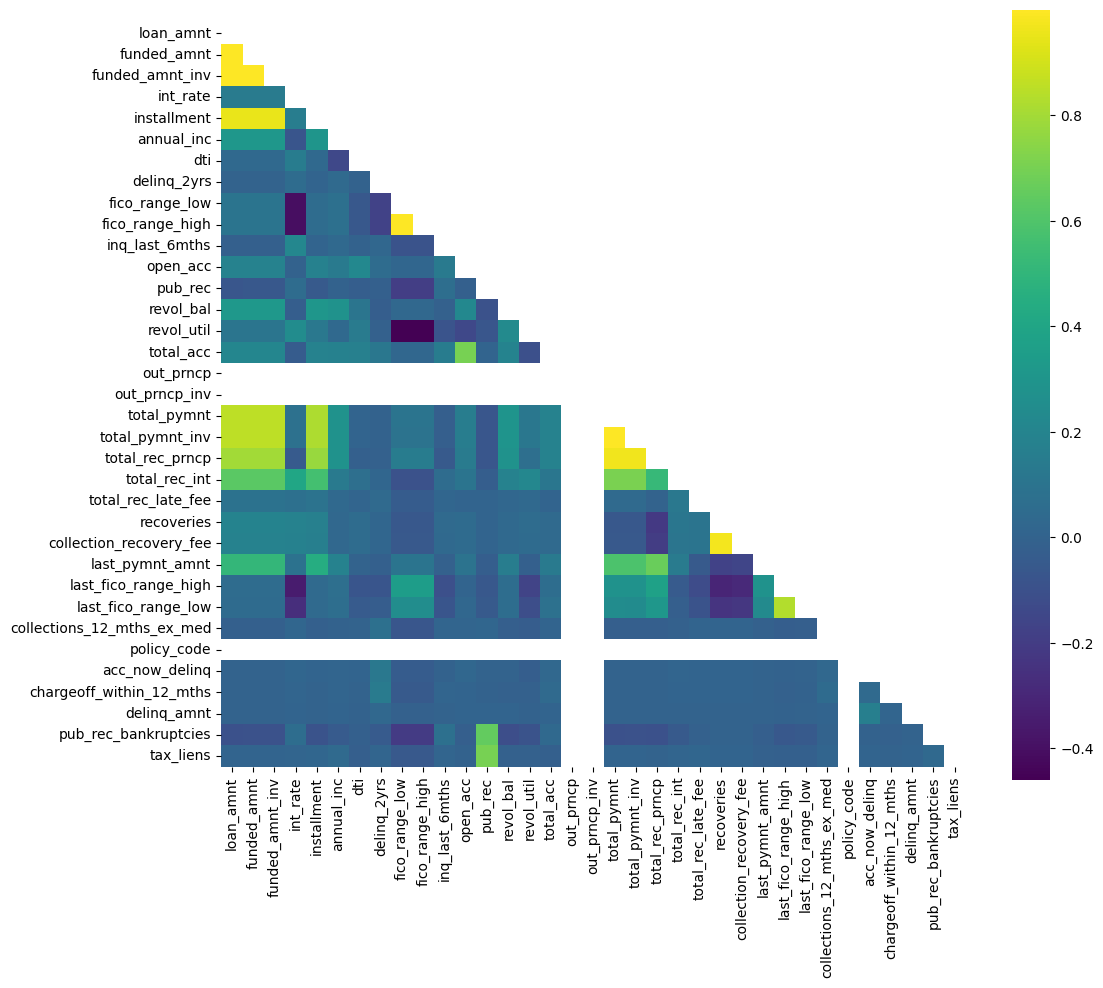

In [ ]:
df_numeric = df_accepted.select_dtypes(include=[np.number])

plt.figure(figsize=(12,10))
mask = np.zeros_like(df_numeric.corr())
mask[np.triu_indices_from(mask)] = True
sns.heatmap(df_numeric.corr(), cmap='viridis', mask=mask, annot=False, square=True)

In [ ]:
print(df_accepted.out_prncp.value_counts())
print(df_accepted.out_prncp_inv.value_counts())
print(df_accepted.policy_code.value_counts())

out_prncp
0.0    1341026
Name: count, dtype: int64
out_prncp_inv
0.0    1341026
Name: count, dtype: int64
policy_code
1.0    1341026
Name: count, dtype: int64


In [ ]:
cols_to_drop = ['out_prncp', 'out_prncp_inv', 'policy_code']
df_accepted = df_accepted.drop(columns=cols_to_drop)
df_accepted.shape

(1341026, 53)

<Axes: >

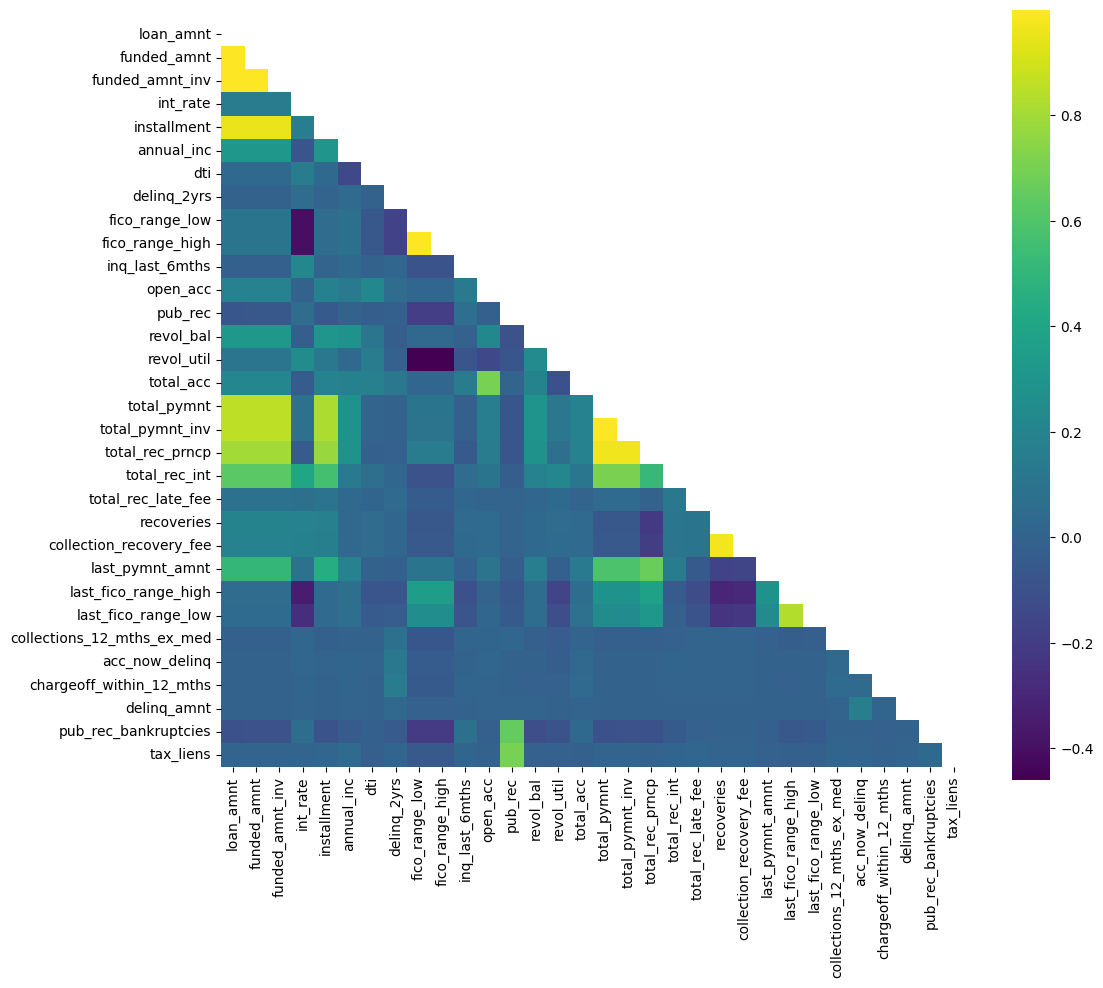

In [ ]:
df_numeric = df_accepted.select_dtypes(include=[np.number])

plt.figure(figsize=(12,10))
mask = np.zeros_like(df_numeric.corr())
mask[np.triu_indices_from(mask)] = True
sns.heatmap(df_numeric.corr(), cmap='viridis', mask=mask, annot=False, square=True)

In [ ]:
# unstacking correlation to check highest correlation pairs

c = df_numeric.corr().abs()
unstack_corr = c.unstack()
pairs = unstack_corr.sort_values(ascending=False)

corr_pairs = pd.DataFrame(pairs).drop_duplicates().reset_index()
corr_pairs.columns = ['feature1', 'feature2', 'corr']


# check feature pairs above 0.8 in correlation

cond1 = (corr_pairs.feature1 != corr_pairs.feature2)
cond2 = (corr_pairs['corr']>0.80)

corr_pairs[cond1 & cond2]

,feature1,feature2,corr
1,fico_range_high,fico_range_low,1.000000
2,loan_amnt,funded_amnt,0.999565
3,total_pymnt_inv,total_pymnt,0.999541
4,funded_amnt,funded_amnt_inv,0.999439
5,funded_amnt_inv,loan_amnt,0.998918
6,recoveries,collection_recovery_fee,0.972674
7,total_rec_prncp,total_pymnt,0.967104
8,total_pymnt_inv,total_rec_prncp,0.966725
9,funded_amnt,installment,0.954037
10,funded_amnt_inv,installment,0.953445


<Axes: xlabel='fico_range_low', ylabel='fico_range_high'>

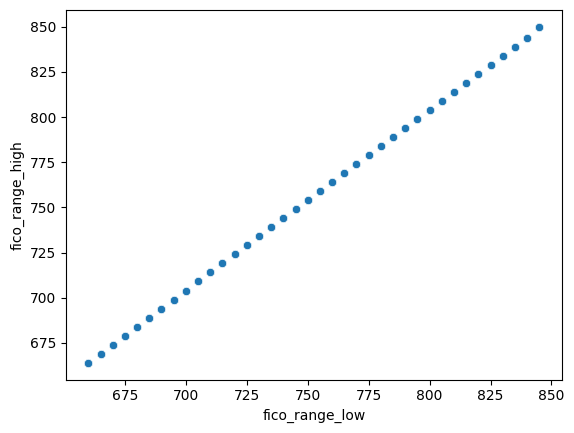

In [ ]:
sns.scatterplot(x=df_accepted.fico_range_low, y=df_accepted.fico_range_high)

<Axes: xlabel='funded_amnt', ylabel='loan_amnt'>

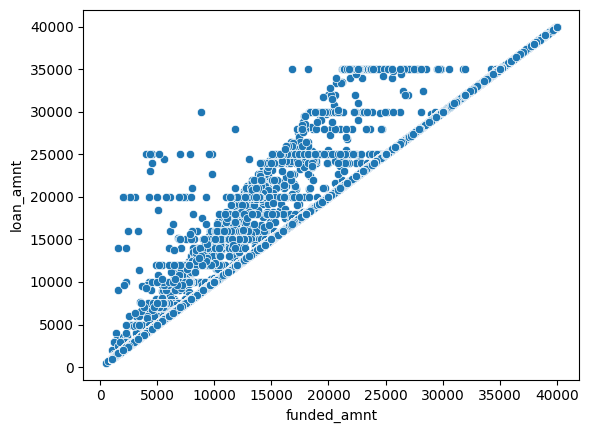

In [ ]:
sns.scatterplot(x=df_accepted.funded_amnt, y=df_accepted.loan_amnt)

<Axes: xlabel='funded_amnt', ylabel='funded_amnt_inv'>

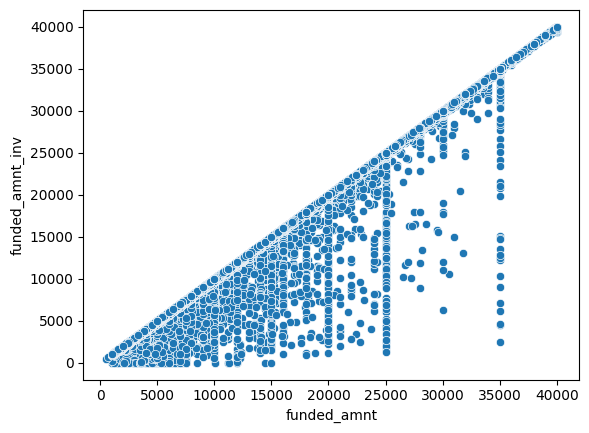

In [ ]:
sns.scatterplot(x=df_accepted.funded_amnt, y=df_accepted.funded_amnt_inv)

<Axes: xlabel='total_pymnt', ylabel='installment'>

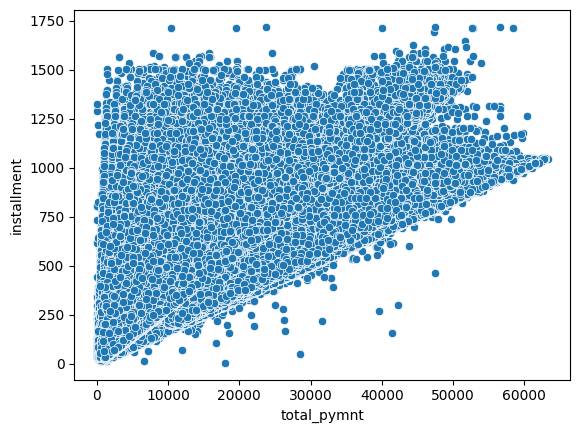

In [ ]:
sns.scatterplot(x=df_accepted.total_pymnt, y=df_accepted.installment)

In [ ]:
cols_to_drop = ['fico_range_low', 'funded_amnt_inv', 'funded_amnt', 'total_pymnt_inv', 'total_pymnt', 'installment', 'collection_recovery_fee', 'total_rec_prncp', 'last_fico_range_low']
df_accepted = df_accepted.drop(columns=cols_to_drop)
df_accepted.shape

(1341026, 44)

In [ ]:
print(df_accepted.columns)

Index(['id', 'loan_amnt', 'term', 'int_rate', 'grade', 'sub_grade',
       'home_ownership', 'annual_inc', 'verification_status', 'issue_d',
       'loan_status', 'pymnt_plan', 'url', 'purpose', 'zip_code', 'addr_state',
       'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_high',
       'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
       'total_acc', 'initial_list_status', 'total_rec_int',
       'total_rec_late_fee', 'recoveries', 'last_pymnt_d', 'last_pymnt_amnt',
       'last_credit_pull_d', 'last_fico_range_high',
       'collections_12_mths_ex_med', 'application_type', 'acc_now_delinq',
       'chargeoff_within_12_mths', 'delinq_amnt', 'pub_rec_bankruptcies',
       'tax_liens', 'hardship_flag', 'disbursement_method',
       'debt_settlement_flag'],
      dtype='object')


In [ ]:
values = df_accepted.loan_status.unique()
encode = [1,0]
d = dict(zip(values, encode))

In [ ]:
df_accepted['loan_paid'] = df_accepted['loan_status'].map(d)

df_accepted = df_accepted.drop(columns=['loan_status'])

<Axes: >

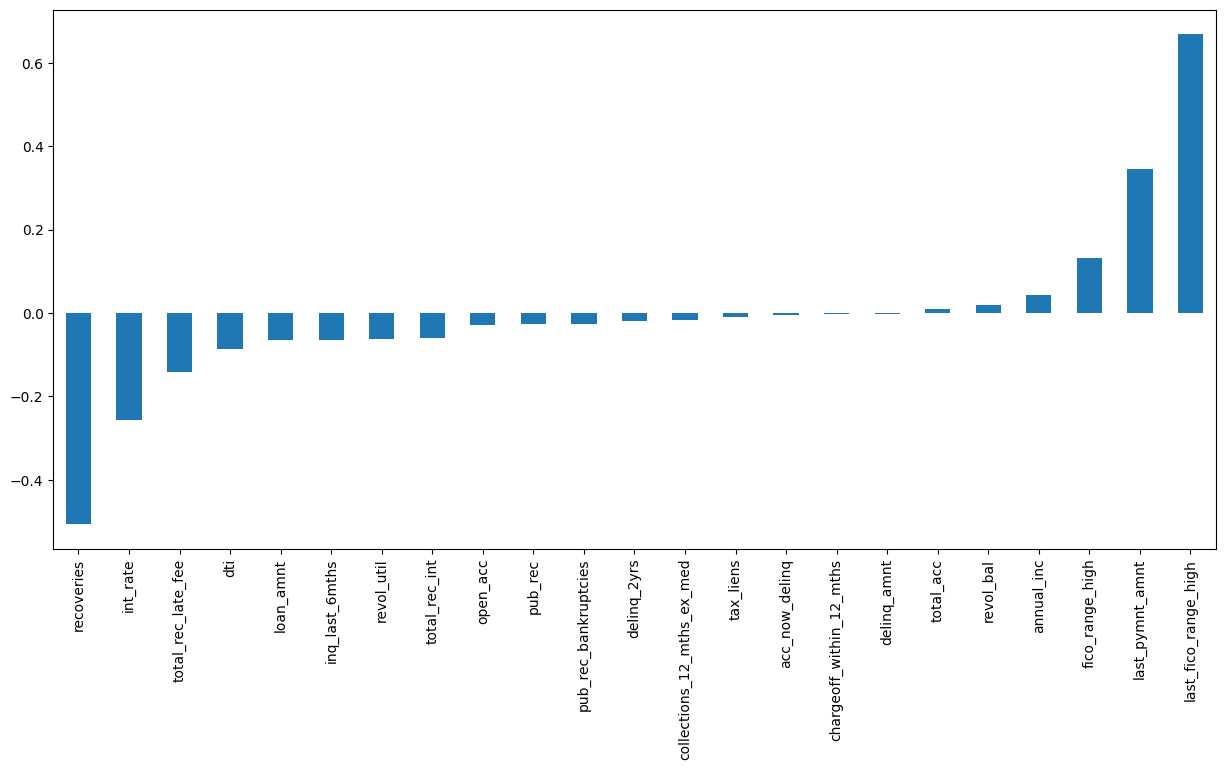

In [ ]:
df_numeric = df_accepted.select_dtypes(include=[np.number])

# checking correlation of features to the new loan_paid column

plt.figure(figsize=(15,7))
new_corr = df_numeric.corr().iloc[:-1,-1].sort_values()
new_corr.plot.bar(rot=90)

In [ ]:
df_accepted.head()

,id,loan_amnt,term,int_rate,grade,sub_grade,home_ownership,annual_inc,verification_status,issue_d,...,application_type,acc_now_delinq,chargeoff_within_12_mths,delinq_amnt,pub_rec_bankruptcies,tax_liens,hardship_flag,disbursement_method,debt_settlement_flag,loan_paid
0,68407277,3600.0,36 months,13.99,C,C4,MORTGAGE,55000.0,Not Verified,Dec-2015,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,1
1,68355089,24700.0,36 months,11.99,C,C1,MORTGAGE,65000.0,Not Verified,Dec-2015,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,1
2,68341763,20000.0,60 months,10.78,B,B4,MORTGAGE,63000.0,Not Verified,Dec-2015,...,Joint App,0.0,0.0,0.0,0.0,0.0,N,Cash,N,1
4,68476807,10400.0,60 months,22.45,F,F1,MORTGAGE,104433.0,Source Verified,Dec-2015,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,1
5,68426831,11950.0,36 months,13.44,C,C3,RENT,34000.0,Source Verified,Dec-2015,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,1


In [ ]:
cat_cols = df_accepted.select_dtypes(include=['object']).columns
print(cat_cols)
df_accepted[cat_cols]

Index(['id', 'term', 'grade', 'sub_grade', 'home_ownership',
       'verification_status', 'issue_d', 'pymnt_plan', 'url', 'purpose',
       'zip_code', 'addr_state', 'earliest_cr_line', 'initial_list_status',
       'last_pymnt_d', 'last_credit_pull_d', 'application_type',
       'hardship_flag', 'disbursement_method', 'debt_settlement_flag'],
      dtype='object')


,id,term,grade,sub_grade,home_ownership,verification_status,issue_d,pymnt_plan,url,purpose,zip_code,addr_state,earliest_cr_line,initial_list_status,last_pymnt_d,last_credit_pull_d,application_type,hardship_flag,disbursement_method,debt_settlement_flag
0,68407277,36 months,C,C4,MORTGAGE,Not Verified,Dec-2015,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,190xx,PA,Aug-2003,w,Jan-2019,Mar-2019,Individual,N,Cash,N
1,68355089,36 months,C,C1,MORTGAGE,Not Verified,Dec-2015,n,https://lendingclub.com/browse/loanDetail.acti...,small_business,577xx,SD,Dec-1999,w,Jun-2016,Mar-2019,Individual,N,Cash,N
2,68341763,60 months,B,B4,MORTGAGE,Not Verified,Dec-2015,n,https://lendingclub.com/browse/loanDetail.acti...,home_improvement,605xx,IL,Aug-2000,w,Jun-2017,Mar-2019,Joint App,N,Cash,N
4,68476807,60 months,F,F1,MORTGAGE,Source Verified,Dec-2015,n,https://lendingclub.com/browse/loanDetail.acti...,major_purchase,174xx,PA,Jun-1998,w,Jul-2016,Mar-2018,Individual,N,Cash,N
5,68426831,36 months,C,C3,RENT,Source Verified,Dec-2015,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,300xx,GA,Oct-1987,w,May-2017,May-2017,Individual,N,Cash,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260688,89905081,60 months,B,B2,OWN,Not Verified,Oct-2016,n,https://lendingclub.com/browse/loanDetail.acti...,home_improvement,775xx,TX,Jul-2004,f,Aug-2018,Mar-2019,Individual,N,Cash,N
2260690,88948836,60 months,C,C3,MORTGAGE,Not Verified,Oct-2016,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,900xx,CA,Mar-2002,f,Jul-2018,Jul-2018,Individual,N,Cash,N
2260691,89996426,60 months,C,C4,MORTGAGE,Source Verified,Oct-2016,n,https://lendingclub.com/browse/loanDetail.acti...,home_improvement,863xx,AZ,Jun-2011,f,Mar-2017,Dec-2018,Individual,N,Cash,N
2260692,90006534,60 months,C,C1,RENT,Not Verified,Oct-2016,n,https://lendingclub.com/browse/loanDetail.acti...,medical,284xx,NC,Aug-1997,f,Mar-2018,Mar-2019,Individual,N,Cash,N


In [ ]:
# droping constant columns

print(df_accepted.pymnt_plan.value_counts())
print(df_accepted.hardship_flag.value_counts())

cols_to_drop = ['id', 'pymnt_plan', 'hardship_flag']
df_accepted = df_accepted.drop(columns=cols_to_drop)
df_accepted.shape

pymnt_plan
n    1341026
Name: count, dtype: int64
hardship_flag
N    1341026
Name: count, dtype: int64


(1341026, 41)

In [ ]:
cat_cols = df_accepted.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['term', 'grade', 'sub_grade', 'home_ownership', 'verification_status',
       'issue_d', 'url', 'purpose', 'zip_code', 'addr_state',
       'earliest_cr_line', 'initial_list_status', 'last_pymnt_d',
       'last_credit_pull_d', 'application_type', 'disbursement_method',
       'debt_settlement_flag'],
      dtype='object')


In [ ]:
print(df_accepted.term.value_counts())

# convert term into either a 36 or 60 integer numeric data type

l1 = df_accepted.term.unique()
l2 = [36, 60]
d = dict(zip(l1, l2))

df_accepted['term'] = df_accepted['term'].map(d)

term
36 months    1017398
60 months     323628
Name: count, dtype: int64


In [ ]:
df_accepted['term']

,term
0,36
1,36
2,60
4,60
5,36
...,...
2260688,60
2260690,60
2260691,60
2260692,60


In [ ]:
cat_cols = df_accepted.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['grade', 'sub_grade', 'home_ownership', 'verification_status',
       'issue_d', 'url', 'purpose', 'zip_code', 'addr_state',
       'earliest_cr_line', 'initial_list_status', 'last_pymnt_d',
       'last_credit_pull_d', 'application_type', 'disbursement_method',
       'debt_settlement_flag'],
      dtype='object')


In [ ]:
print(df_accepted.grade.value_counts())
print(df_accepted.sub_grade.value_counts())

grade
B    391850
C    380490
A    234657
D    200019
E     93126
F     31854
G      9030
Name: count, dtype: int64
sub_grade
C1    85247
B4    83003
B5    82327
B3    81658
C2    78960
C3    74781
C4    74173
B2    73870
B1    70992
C5    67329
A5    63892
A4    52135
D1    51092
D2    44637
A1    43634
D3    39134
A3    37900
A2    37096
D4    35412
D5    29744
E1    23657
E2    21244
E3    18279
E4    15621
E5    14325
F1     9914
F2     7149
F3     6055
F4     4826
F5     3910
G1     2967
G2     2109
G3     1600
G4     1259
G5     1095
Name: count, dtype: int64


<Axes: xlabel='grade', ylabel='count'>

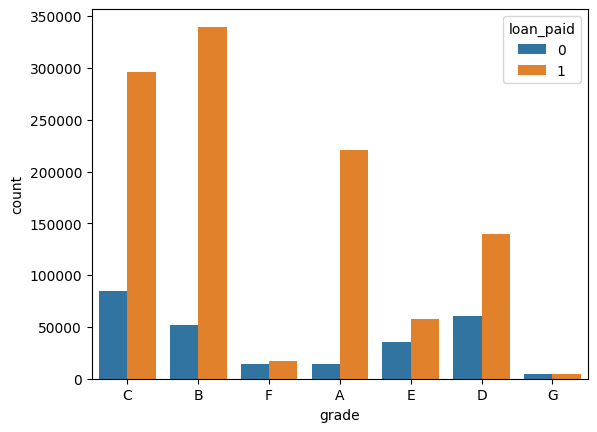

In [ ]:
# checking count per grade and loan_paid

sns.countplot(x=df_accepted.grade, hue=df_accepted.loan_paid)

<Axes: xlabel='sub_grade', ylabel='count'>

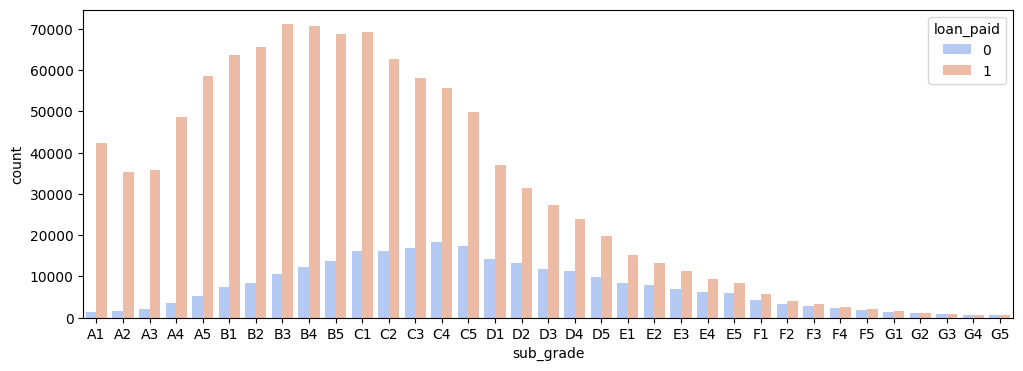

In [ ]:
# checking count per subgrade and loan_paid

l = list(df_accepted.sub_grade.unique())
l.sort()

plt.figure(figsize=(12,4))
sns.countplot(x=df_accepted.sub_grade, order=l, hue=df_accepted.loan_paid, palette='coolwarm')

In [ ]:
# as grade is part of sub_grade, so let's just drop the grade feature.

df_accepted = df_accepted.drop(columns='grade')

In [ ]:
df_accepted = pd.get_dummies(df_accepted, columns = ['sub_grade'], prefix='', prefix_sep='', drop_first=True)

In [ ]:
cat_cols = df_accepted.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['home_ownership', 'verification_status', 'issue_d', 'url', 'purpose',
       'zip_code', 'addr_state', 'earliest_cr_line', 'initial_list_status',
       'last_pymnt_d', 'last_credit_pull_d', 'application_type',
       'disbursement_method', 'debt_settlement_flag'],
      dtype='object')


In [ ]:
print(df_accepted.verification_status.unique())
print(df_accepted.application_type.unique())
print(df_accepted.initial_list_status.unique())
print(df_accepted.purpose.unique())

['Not Verified' 'Source Verified' 'Verified']
['Individual' 'Joint App']
['w' 'f']
['debt_consolidation' 'small_business' 'home_improvement' 'major_purchase'
 'credit_card' 'other' 'house' 'vacation' 'car' 'medical' 'moving'
 'renewable_energy' 'wedding' 'educational']


In [ ]:
# for these columns, let's just create dummy variables, concatenate them with the original dataframe and drop original columns.

df_accepted = pd.get_dummies(df_accepted, columns = ['verification_status'], prefix='', prefix_sep='', drop_first=True)
df_accepted = pd.get_dummies(df_accepted, columns = ['application_type'], prefix='', prefix_sep='', drop_first=True)
df_accepted = pd.get_dummies(df_accepted, columns = ['initial_list_status'], prefix='', prefix_sep='', drop_first=True)
df_accepted = pd.get_dummies(df_accepted, columns = ['purpose'], prefix='', prefix_sep='', drop_first=True)

In [ ]:
cat_cols = df_accepted.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['home_ownership', 'issue_d', 'url', 'zip_code', 'addr_state',
       'earliest_cr_line', 'last_pymnt_d', 'last_credit_pull_d',
       'disbursement_method', 'debt_settlement_flag'],
      dtype='object')


In [ ]:
df_accepted.home_ownership.value_counts()

,count
home_ownership,
MORTGAGE,663868
RENT,532493
OWN,144195
ANY,283
OTHER,142
NONE,45


In [ ]:
df_accepted['home_ownership'] = df_accepted.home_ownership.replace('NONE', 'ANY')
df_accepted = pd.get_dummies(df_accepted, columns = ['home_ownership'], prefix='', prefix_sep='', drop_first=True)

In [ ]:
cat_cols = df_accepted.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['issue_d', 'url', 'zip_code', 'addr_state', 'earliest_cr_line',
       'last_pymnt_d', 'last_credit_pull_d', 'disbursement_method',
       'debt_settlement_flag'],
      dtype='object')


In [ ]:
df_accepted.issue_d.head(10)

,issue_d
0,Dec-2015
1,Dec-2015
2,Dec-2015
4,Dec-2015
5,Dec-2015
6,Dec-2015
7,Dec-2015
8,Dec-2015
9,Dec-2015
12,Dec-2015


In [ ]:
df_accepted = df_accepted.drop(columns=['url', 'last_pymnt_d', 'last_credit_pull_d'])

In [ ]:
df_accepted.zip_code.value_counts()

,count
zip_code,
945xx,14964
750xx,14440
112xx,13781
606xx,12407
300xx,12087
...,...
516xx,1
511xx,1
896xx,1


In [ ]:
df_accepted = df_accepted.drop(columns=['zip_code', 'addr_state'])

In [ ]:
cat_cols = df_accepted.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['issue_d', 'earliest_cr_line', 'disbursement_method',
       'debt_settlement_flag'],
      dtype='object')


In [ ]:
print(df_accepted.disbursement_method.value_counts())
print(df_accepted.debt_settlement_flag.value_counts())

disbursement_method
Cash         1334162
DirectPay       6864
Name: count, dtype: int64
debt_settlement_flag
N    1307844
Y      33182
Name: count, dtype: int64


In [ ]:
df_accepted = pd.get_dummies(df_accepted, columns = ['disbursement_method'], prefix='', prefix_sep='', drop_first=True)
df_accepted = pd.get_dummies(df_accepted, columns = ['debt_settlement_flag'], prefix='', prefix_sep='', drop_first=True)

In [ ]:
print(df_accepted.earliest_cr_line.value_counts())

earliest_cr_line
Aug-2001    9365
Aug-2002    9066
Sep-2003    9000
Oct-2001    8838
Aug-2000    8822
            ... 
Nov-1957       1
Aug-1951       1
May-1961       1
Aug-1955       1
Apr-1958       1
Name: count, Length: 739, dtype: int64


In [ ]:
df_accepted = df_accepted.drop(columns=['earliest_cr_line'])

In [ ]:
print(df_accepted.columns)

Index(['loan_amnt', 'term', 'int_rate', 'annual_inc', 'issue_d', 'dti',
       'delinq_2yrs', 'fico_range_high', 'inq_last_6mths', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'total_rec_int',
       'total_rec_late_fee', 'recoveries', 'last_pymnt_amnt',
       'last_fico_range_high', 'collections_12_mths_ex_med', 'acc_now_delinq',
       'chargeoff_within_12_mths', 'delinq_amnt', 'pub_rec_bankruptcies',
       'tax_liens', 'loan_paid', 'A2', 'A3', 'A4', 'A5', 'B1', 'B2', 'B3',
       'B4', 'B5', 'C1', 'C2', 'C3', 'C4', 'C5', 'D1', 'D2', 'D3', 'D4', 'D5',
       'E1', 'E2', 'E3', 'E4', 'E5', 'F1', 'F2', 'F3', 'F4', 'F5', 'G1', 'G2',
       'G3', 'G4', 'G5', 'Source Verified', 'Verified', 'Joint App', 'w',
       'credit_card', 'debt_consolidation', 'educational', 'home_improvement',
       'house', 'major_purchase', 'medical', 'moving', 'other',
       'renewable_energy', 'small_business', 'vacation', 'wedding', 'MORTGAGE',
       'OTHER', 'OWN', 'RENT', 'Direc

In [ ]:
df_accepted['issue_year'] = pd.to_datetime(df_accepted['issue_d'], format='%b-%Y').dt.year
df_accepted['issue_year'].value_counts().sort_index()

,count
issue_year,
2007,5
2008,1104
2009,4688
2010,11497
2011,21675
2012,53260
2013,134626
2014,222822
2015,375088


In [ ]:
print(df_accepted.columns)

Index(['loan_amnt', 'term', 'int_rate', 'annual_inc', 'issue_d', 'dti',
       'delinq_2yrs', 'fico_range_high', 'inq_last_6mths', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'total_rec_int',
       'total_rec_late_fee', 'recoveries', 'last_pymnt_amnt',
       'last_fico_range_high', 'collections_12_mths_ex_med', 'acc_now_delinq',
       'chargeoff_within_12_mths', 'delinq_amnt', 'pub_rec_bankruptcies',
       'tax_liens', 'loan_paid', 'A2', 'A3', 'A4', 'A5', 'B1', 'B2', 'B3',
       'B4', 'B5', 'C1', 'C2', 'C3', 'C4', 'C5', 'D1', 'D2', 'D3', 'D4', 'D5',
       'E1', 'E2', 'E3', 'E4', 'E5', 'F1', 'F2', 'F3', 'F4', 'F5', 'G1', 'G2',
       'G3', 'G4', 'G5', 'Source Verified', 'Verified', 'Joint App', 'w',
       'credit_card', 'debt_consolidation', 'educational', 'home_improvement',
       'house', 'major_purchase', 'medical', 'moving', 'other',
       'renewable_energy', 'small_business', 'vacation', 'wedding', 'MORTGAGE',
       'OTHER', 'OWN', 'RENT', 'Direc

In [ ]:
df_accepted = df_accepted.drop(columns=['delinq_2yrs',
                                        'revol_bal',
                                        'open_acc',
                                        'last_fico_range_high',
                                        'inq_last_6mths',
                                        'total_rec_late_fee',
                                        'total_acc',
                                        'revol_util',
                                        'last_pymnt_amnt',
                                        'delinq_amnt',
                                        'acc_now_delinq',
                                        'total_rec_int',
                                        'Y',
                                        'recoveries'])

In [ ]:
print(df_accepted.columns)

Index(['loan_amnt', 'term', 'int_rate', 'annual_inc', 'issue_d', 'dti',
       'fico_range_high', 'pub_rec', 'collections_12_mths_ex_med',
       'chargeoff_within_12_mths', 'pub_rec_bankruptcies', 'tax_liens',
       'loan_paid', 'A2', 'A3', 'A4', 'A5', 'B1', 'B2', 'B3', 'B4', 'B5', 'C1',
       'C2', 'C3', 'C4', 'C5', 'D1', 'D2', 'D3', 'D4', 'D5', 'E1', 'E2', 'E3',
       'E4', 'E5', 'F1', 'F2', 'F3', 'F4', 'F5', 'G1', 'G2', 'G3', 'G4', 'G5',
       'Source Verified', 'Verified', 'Joint App', 'w', 'credit_card',
       'debt_consolidation', 'educational', 'home_improvement', 'house',
       'major_purchase', 'medical', 'moving', 'other', 'renewable_energy',
       'small_business', 'vacation', 'wedding', 'MORTGAGE', 'OTHER', 'OWN',
       'RENT', 'DirectPay', 'issue_year'],
      dtype='object')


<Axes: >

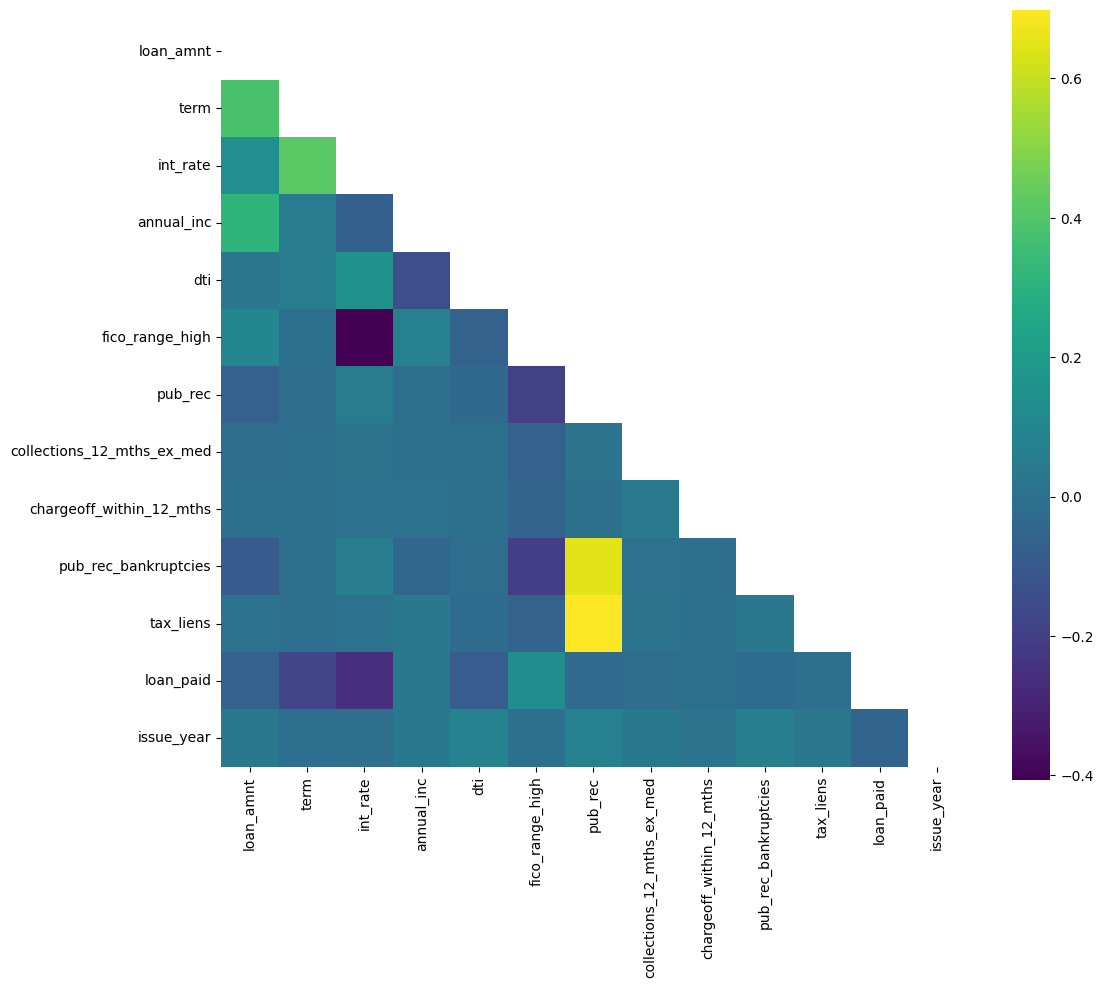

In [ ]:
df_numeric = df_accepted.select_dtypes(include=[np.number])

plt.figure(figsize=(12,10))
mask = np.zeros_like(df_numeric.corr())
mask[np.triu_indices_from(mask)] = True
sns.heatmap(df_numeric.corr(), cmap='viridis', mask=mask, annot=False, square=True)

In [ ]:
# Neural Network

# sampling data
# df = df_accepted.sample(frac=0.8, random_state=42)
# print(len(df))

df = df_accepted.copy()

# Garantir que issue_d está no formato datetime e ordenar cronologicamente
df['issue_d'] = pd.to_datetime(df['issue_d'])
df = df.sort_values('issue_d').reset_index(drop=True)

# Calcular os índices de corte
n = len(df)
train_end = int(n * 0.70)   # 70% treino
test_end  = int(n * 0.80)   # 10% teste (90% - 70%)
                             # 20% teste final (100% - 90%)

# Separar os conjuntos mantendo a ordem temporal
train_df      = df.iloc[:train_end]
test_df       = df.iloc[train_end:test_end]
test_final_df = df.iloc[test_end:]

# Verificação dos períodos de cada conjunto
print("Treino:     ", train_df['issue_d'].min().date(), "→", train_df['issue_d'].max().date(), f"({len(train_df):,} registros)")
print("Teste:      ", test_df['issue_d'].min().date(), "→", test_df['issue_d'].max().date(), f"({len(test_df):,} registros)")
print("Teste Final:", test_final_df['issue_d'].min().date(), "→", test_final_df['issue_d'].max().date(), f"({len(test_final_df):,} registros)")

# Remover issue_d antes de gerar X e y (usado apenas para ordenação)
cols_to_exclude = ['loan_paid', 'issue_d']

X_train      = train_df.drop(columns=cols_to_exclude).values
y_train      = train_df['loan_paid'].values

X_test       = test_df.drop(columns=cols_to_exclude).values
y_test       = test_df['loan_paid'].values

X_test_final = test_final_df.drop(columns=cols_to_exclude).values
y_test_final = test_final_df['loan_paid'].values

/tmp/ipykernel_7269/1170565309.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['issue_d'] = pd.to_datetime(df['issue_d'])


Treino:      2007-10-01 → 2016-04-01 (938,718 registros)
Teste:       2016-04-01 → 2016-10-01 (134,102 registros)
Teste Final: 2016-10-01 → 2018-12-01 (268,206 registros)


In [ ]:
scaler = MinMaxScaler()


X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_test_final = scaler.transform(X_test_final)

# Verifique as formas dos conjuntos de dados
print("Tamanho do conjunto de treino:", X_train.shape)
print("Tamanho do conjunto de teste:", X_test.shape)
print("Tamanho do conjunto de teste final:", X_test_final.shape)


Tamanho do conjunto de treino: (938718, 68)
Tamanho do conjunto de teste: (134102, 68)
Tamanho do conjunto de teste final: (268206, 68)


In [ ]:
# Building Model 1

model1 = Sequential()
model1.add(Dense(units=78,activation='relu'))
model1.add(Dense(units=39,activation='relu'))
model1.add(Dense(units=19,activation='relu'))
model1.add(Dense(units=8,activation='relu'))
model1.add(Dense(units=4,activation='relu'))
model1.add(Dense(units=1,activation='sigmoid'))

model1.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
model1.fit(x=X_train,
          y=y_train,
          epochs=40,
          batch_size=512,
          validation_data=(X_test, y_test), verbose=1)

Epoch 1/40
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8121 - loss: 0.4461 - val_accuracy: 0.7521 - val_loss: 0.5293
Epoch 2/40
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8164 - loss: 0.4350 - val_accuracy: 0.7522 - val_loss: 0.5263
Epoch 3/40
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8168 - loss: 0.4338 - val_accuracy: 0.7522 - val_loss: 0.5244
Epoch 4/40
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8169 - loss: 0.4333 - val_accuracy: 0.7539 - val_loss: 0.5217
Epoch 5/40
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8171 - loss: 0.4330 - val_accuracy: 0.7539 - val_loss: 0.5267
Epoch 6/40
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8171 - loss: 0.4327 - val_accuracy: 0.7540 - val_loss: 0.5255
Epoch 7/40
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8170 - loss: 0.4326 - val_accuracy: 0.7530 - val_loss: 0.5263
Epoch 8/40
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8173 - loss: 0.4324 - 

In [ ]:
# building model2

model2 = Sequential()
model2.add(Dense(units=64,activation='relu'))
model2.add(Dense(units=32,activation='relu'))
model2.add(Dense(units=8,activation='relu'))
model2.add(Dense(units=4,activation='relu'))
model2.add(Dense(units=1,activation='sigmoid'))

model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
model2.fit(x=X_train,
          y=y_train,
          epochs=40,
          batch_size=512,
          validation_data=(X_test, y_test), verbose=1)

Epoch 1/40
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8133 - loss: 0.4428 - val_accuracy: 0.7522 - val_loss: 0.5254
Epoch 2/40
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8161 - loss: 0.4351 - val_accuracy: 0.7528 - val_loss: 0.5313
Epoch 3/40
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8165 - loss: 0.4340 - val_accuracy: 0.7524 - val_loss: 0.5265
Epoch 4/40
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8168 - loss: 0.4335 - val_accuracy: 0.7533 - val_loss: 0.5277
Epoch 5/40
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8169 - loss: 0.4331 - val_accuracy: 0.7539 - val_loss: 0.5276
Epoch 6/40
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8169 - loss: 0.4329 - val_accuracy: 0.7539 - val_loss: 0.5223
Epoch 7/40
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8171 - loss: 0.4327 - val_accuracy: 0.7541 - val_loss: 0.5277
Epoch 8/40
1834/1834 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8172 - loss: 0.4325 - 

In [ ]:
# building model3

model3 = Sequential()
model3.add(Dense(units=8,activation='relu'))
model3.add(Dense(units=1,activation='sigmoid'))

model3.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
model3.fit(x=X_train,
          y=y_train,
          epochs=40,
          batch_size=512,
          validation_data=(X_test, y_test), verbose=1)

In [ ]:
# building model4

model4 = Sequential()
model4.add(Dense(units=128,activation='relu'))
model4.add(Dense(units=64,activation='relu'))
model4.add(Dense(units=32,activation='relu'))
model4.add(Dense(units=8,activation='relu'))
model4.add(Dense(units=4,activation='relu'))
model4.add(Dense(units=1,activation='sigmoid'))

model4.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
model4.fit(x=X_train,
          y=y_train,
          epochs=40,
          batch_size=128,
          validation_data=(X_test, y_test), verbose=1)

In [ ]:
# building model5

model5 = Sequential()
model5.add(Dense(units=128,activation='relu'))
model5.add(Dense(units=64,activation='relu'))
model5.add(Dense(units=32,activation='relu'))
model5.add(Dense(units=8,activation='relu'))
model5.add(Dense(units=4,activation='relu'))
model5.add(Dense(units=1,activation='sigmoid'))

model5.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
model5.fit(x=X_train,
          y=y_train,
          epochs=40,
          batch_size=32,
          validation_data=(X_test, y_test), verbose=1)

Epoch 1/40
29335/29335 ━━━━━━━━━━━━━━━━━━━━ 30s 988us/step - accuracy: 0.8139 - loss: 0.4849 - val_accuracy: 0.7484 - val_loss: 0.5770
Epoch 2/40
29335/29335 ━━━━━━━━━━━━━━━━━━━━ 29s 994us/step - accuracy: 0.8139 - loss: 0.4805 - val_accuracy: 0.7484 - val_loss: 0.5760
Epoch 3/40
29335/29335 ━━━━━━━━━━━━━━━━━━━━ 29s 991us/step - accuracy: 0.8139 - loss: 0.4805 - val_accuracy: 0.7484 - val_loss: 0.5781
Epoch 4/40
29335/29335 ━━━━━━━━━━━━━━━━━━━━ 29s 992us/step - accuracy: 0.8139 - loss: 0.4805 - val_accuracy: 0.7484 - val_loss: 0.5771
Epoch 5/40
29335/29335 ━━━━━━━━━━━━━━━━━━━━ 29s 981us/step - accuracy: 0.8139 - loss: 0.4805 - val_accuracy: 0.7484 - val_loss: 0.5772
Epoch 6/40
29335/29335 ━━━━━━━━━━━━━━━━━━━━ 29s 986us/step - accuracy: 0.8139 - loss: 0.4805 - val_accuracy: 0.7484 - val_loss: 0.5782
Epoch 7/40
29335/29335 ━━━━━━━━━━━━━━━━━━━━ 29s 992us/step - accuracy: 0.8139 - loss: 0.4805 - val_accuracy: 0.7484 - val_loss: 0.5770
Epoch 8/40
29335/29335 ━━━━━━━━━━━━━━━━━━━━ 29s 993us/s

In [ ]:
losses1 = pd.DataFrame(model1.history.history)
losses2 = pd.DataFrame(model2.history.history)
losses3 = pd.DataFrame(model3.history.history)
losses4 = pd.DataFrame(model4.history.history)
losses5 = pd.DataFrame(model5.history.history)

<Axes: >

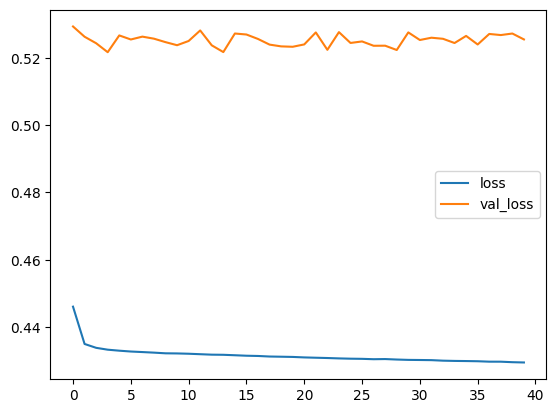

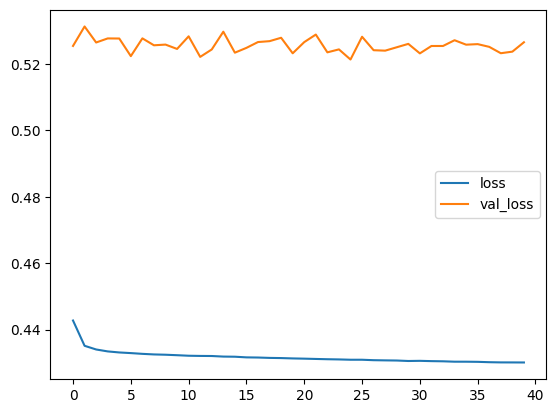

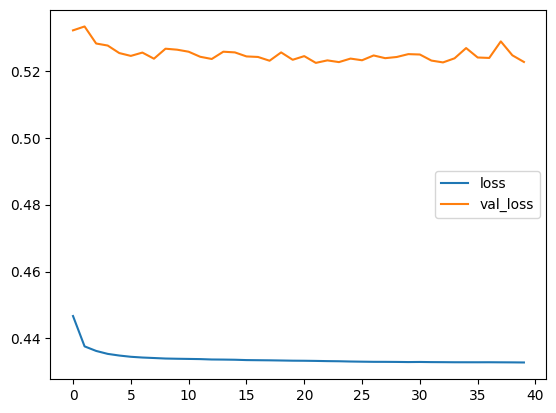

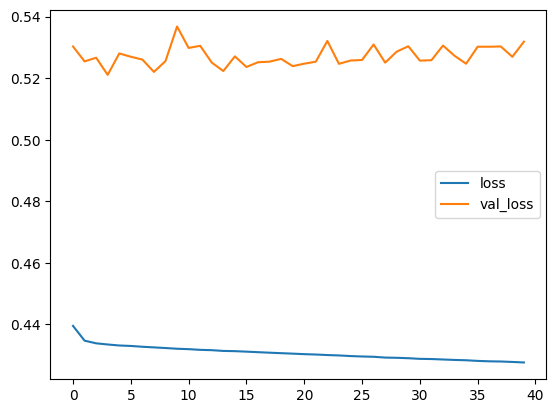

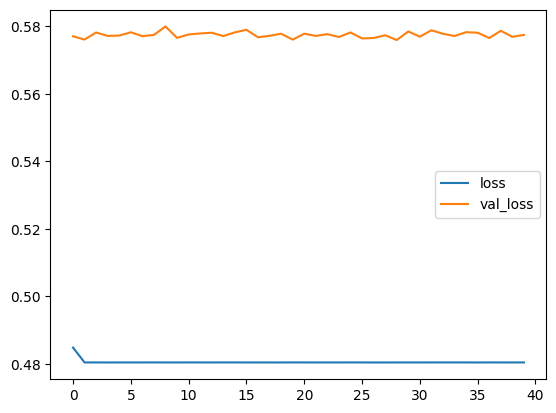

In [ ]:
losses1[['loss','val_loss']].plot()
losses2[['loss','val_loss']].plot()
losses3[['loss','val_loss']].plot()
losses4[['loss','val_loss']].plot()
losses5[['loss','val_loss']].plot()


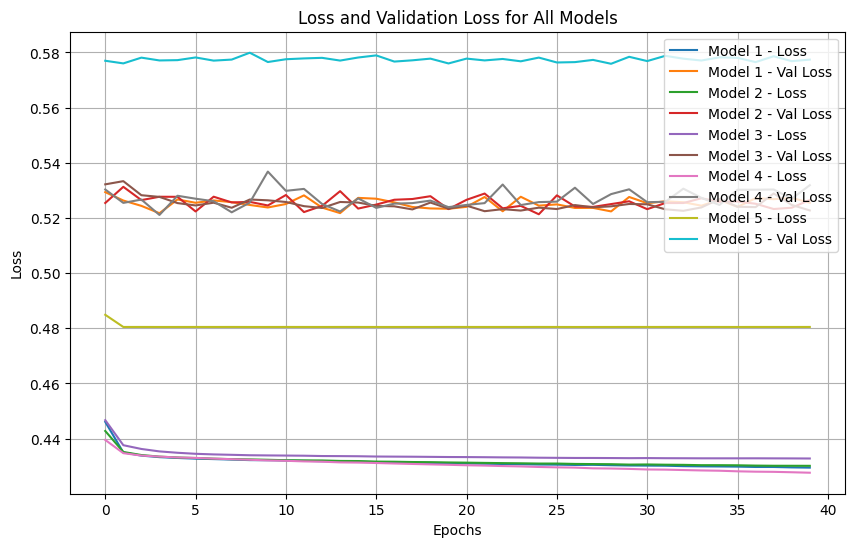

In [ ]:
import matplotlib.pyplot as plt

# Plotar as curvas de loss e val_loss para cada modelo no mesmo gráfico
plt.figure(figsize=(10, 6))  # Define o tamanho da figura

# Modelo 1
plt.plot(losses1['loss'], label='Model 1 - Loss')
plt.plot(losses1['val_loss'], label='Model 1 - Val Loss')

# Modelo 2
plt.plot(losses2['loss'], label='Model 2 - Loss')
plt.plot(losses2['val_loss'], label='Model 2 - Val Loss')

# Modelo 3
plt.plot(losses3['loss'], label='Model 3 - Loss')
plt.plot(losses3['val_loss'], label='Model 3 - Val Loss')

# Modelo 4
plt.plot(losses4['loss'], label='Model 4 - Loss')
plt.plot(losses4['val_loss'], label='Model 4 - Val Loss')

# Modelo 5
plt.plot(losses5['loss'], label='Model 5 - Loss')
plt.plot(losses5['val_loss'], label='Model 5 - Val Loss')

# Configurações adicionais do gráfico
plt.title('Loss and Validation Loss for All Models')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()  # Adiciona a legenda para identificar as curvas
plt.grid(True)  # Adiciona uma grade para facilitar a leitura

# Exibe o gráfico
plt.show()


<Axes: >

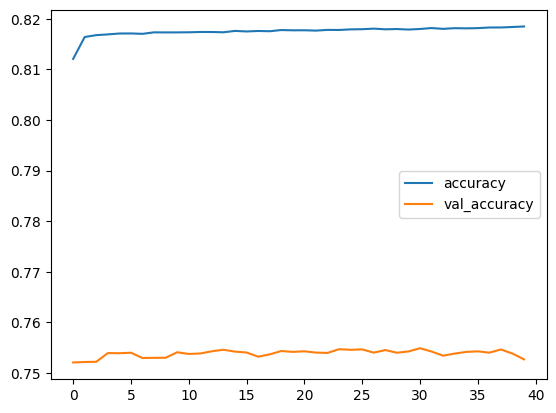

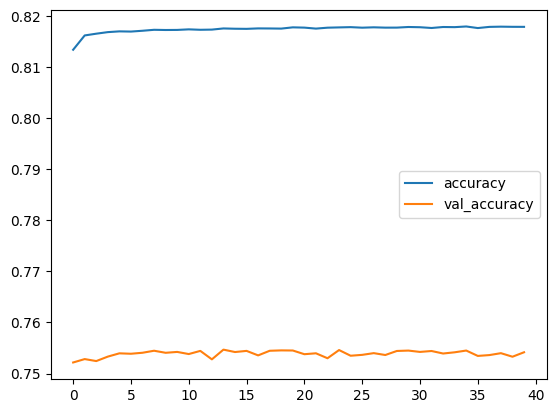

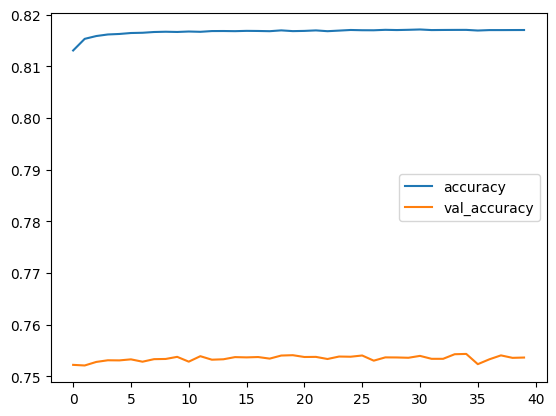

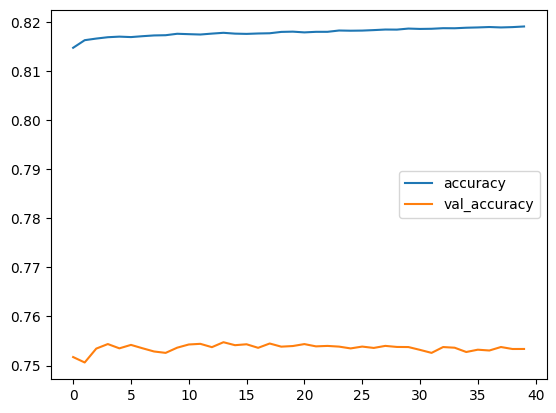

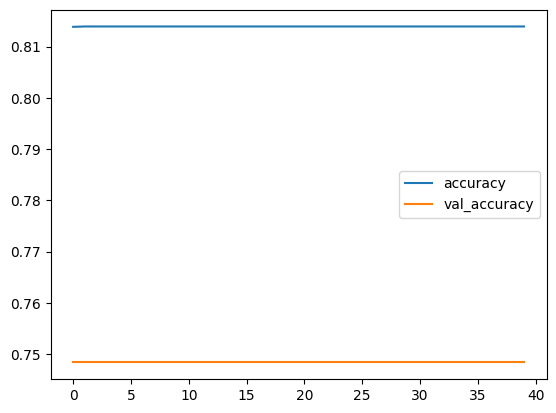

In [ ]:
losses1[['accuracy','val_accuracy']].plot()
losses2[['accuracy','val_accuracy']].plot()
losses3[['accuracy','val_accuracy']].plot()
losses4[['accuracy','val_accuracy']].plot()
losses5[['accuracy','val_accuracy']].plot()

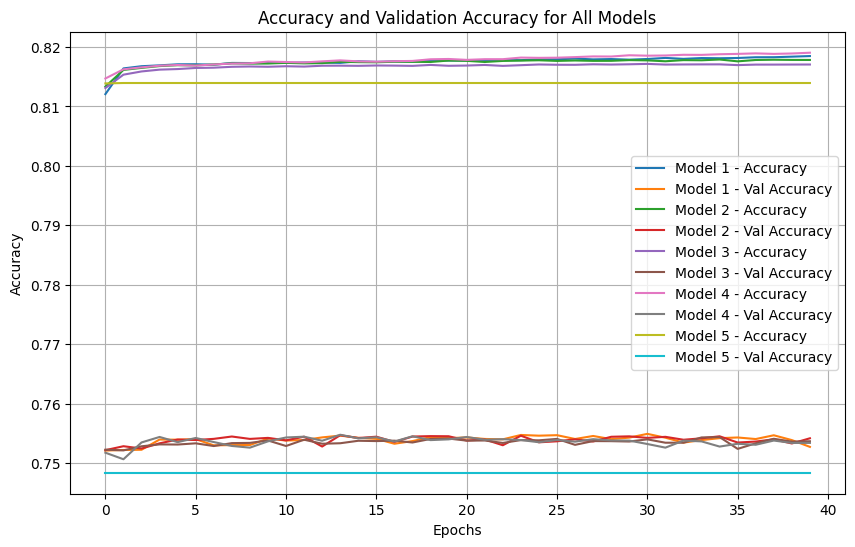

In [ ]:
import matplotlib.pyplot as plt

# Plotar as curvas de accuracy e val_accuracy para cada modelo no mesmo gráfico
plt.figure(figsize=(10, 6))  # Define o tamanho da figura

# Modelo 1
plt.plot(losses1['accuracy'], label='Model 1 - Accuracy')
plt.plot(losses1['val_accuracy'], label='Model 1 - Val Accuracy')

# Modelo 2
plt.plot(losses2['accuracy'], label='Model 2 - Accuracy')
plt.plot(losses2['val_accuracy'], label='Model 2 - Val Accuracy')

# Modelo 3
plt.plot(losses3['accuracy'], label='Model 3 - Accuracy')
plt.plot(losses3['val_accuracy'], label='Model 3 - Val Accuracy')

# Modelo 4
plt.plot(losses4['accuracy'], label='Model 4 - Accuracy')
plt.plot(losses4['val_accuracy'], label='Model 4 - Val Accuracy')

# Modelo 5
plt.plot(losses5['accuracy'], label='Model 5 - Accuracy')
plt.plot(losses5['val_accuracy'], label='Model 5 - Val Accuracy')

# Configurações adicionais do gráfico
plt.title('Accuracy and Validation Accuracy for All Models')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()  # Adiciona a legenda para identificar as curvas
plt.grid(True)  # Adiciona uma grade para facilitar a leitura

# Exibe o gráfico
plt.show()


In [ ]:
predictions1 = (model1.predict(X_train) > 0.5).astype("int32")
print(classification_report(y_train, predictions1))

predictions2 = (model2.predict(X_train) > 0.5).astype("int32")
print(classification_report(y_train, predictions2))

predictions3 = (model3.predict(X_train) > 0.5).astype("int32")
print(classification_report(y_train, predictions3))

predictions4 = (model4.predict(X_train) > 0.5).astype("int32")
print(classification_report(y_train, predictions4))

predictions5 = (model5.predict(X_train) > 0.5).astype("int32")
print(classification_report(y_train, predictions5))

29335/29335 ━━━━━━━━━━━━━━━━━━━━ 12s 413us/step
              precision    recall  f1-score   support

           0       0.57      0.11      0.18    174662
           1       0.83      0.98      0.90    764056

    accuracy                           0.82    938718
   macro avg       0.70      0.54      0.54    938718
weighted avg       0.78      0.82      0.76    938718

29335/29335 ━━━━━━━━━━━━━━━━━━━━ 12s 396us/step
              precision    recall  f1-score   support

           0       0.58      0.08      0.14    174662
           1       0.82      0.99      0.90    764056

    accuracy                           0.82    938718
   macro avg       0.70      0.53      0.52    938718
weighted avg       0.78      0.82      0.76    938718

29335/29335 ━━━━━━━━━━━━━━━━━━━━ 11s 362us/step
              precision    recall  f1-score   support

           0       0.56      0.08      0.14    174662
           1       0.82      0.99      0.90    764056

    accuracy                          

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
predictions11 = model1.predict(X_test)
print(classification_report(y_test, (predictions11> 0.5).astype("int32")))

predictions22 = model2.predict(X_test)
print(classification_report(y_test, (predictions22> 0.5).astype("int32")))

predictions33 = model3.predict(X_test)
print(classification_report(y_test, (predictions33> 0.5).astype("int32")))

predictions44 = model4.predict(X_test)
print(classification_report(y_test, (predictions44> 0.5).astype("int32")))

predictions55 = model5.predict(X_test)
print(classification_report(y_test, (predictions55> 0.5).astype("int32")))

4191/4191 ━━━━━━━━━━━━━━━━━━━━ 2s 404us/step
              precision    recall  f1-score   support

           0       0.53      0.13      0.21     33745
           1       0.77      0.96      0.85    100357

    accuracy                           0.75    134102
   macro avg       0.65      0.55      0.53    134102
weighted avg       0.71      0.75      0.69    134102

4191/4191 ━━━━━━━━━━━━━━━━━━━━ 2s 412us/step
              precision    recall  f1-score   support

           0       0.56      0.11      0.18     33745
           1       0.76      0.97      0.86    100357

    accuracy                           0.75    134102
   macro avg       0.66      0.54      0.52    134102
weighted avg       0.71      0.75      0.69    134102

4191/4191 ━━━━━━━━━━━━━━━━━━━━ 1s 349us/step
              precision    recall  f1-score   support

           0       0.55      0.12      0.20     33745
           1       0.77      0.97      0.85    100357

    accuracy                           0.75    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
predictions111 = (model1.predict(X_test_final)).astype("float")

predictions222 = (model2.predict(X_test_final)).astype("float")

predictions333 = (model3.predict(X_test_final)).astype("float")

predictions444 = (model4.predict(X_test_final)).astype("float")

predictions555 = (model5.predict(X_test_final)).astype("float")


8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 412us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 405us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 355us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 4s 419us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 402us/step


In [ ]:
pd.DataFrame(confusion_matrix(y_test, (predictions11> 0.5).astype("int32")))


,0,1
0,4497,29248
1,3914,96443


In [ ]:
pd.DataFrame(confusion_matrix(y_test, (predictions22> 0.5).astype("int32")))


,0,1
0,3640,30105
1,2863,97494


In [ ]:
pd.DataFrame(confusion_matrix(y_test, (predictions33> 0.5).astype("int32")))


,0,1
0,4064,29681
1,3354,97003


In [ ]:
pd.DataFrame(confusion_matrix(y_test, (predictions44> 0.5).astype("int32")))


,0,1
0,3773,29972
1,3100,97257


In [ ]:
pd.DataFrame(confusion_matrix(y_test, (predictions55> 0.5).astype("int32")))

,0,1
0,0,33745
1,0,100357


In [ ]:
pd.DataFrame(confusion_matrix(y_train, predictions1))


,0,1
0,18565,156097
1,14194,749862


In [ ]:
pd.DataFrame(confusion_matrix(y_train, predictions2))


,0,1
0,13789,160873
1,9803,754253


In [ ]:
pd.DataFrame(confusion_matrix(y_train, predictions3))


,0,1
0,14278,160384
1,11191,752865


In [ ]:
pd.DataFrame(confusion_matrix(y_train, predictions4))


,0,1
0,16485,158177
1,11164,752892


In [ ]:
pd.DataFrame(confusion_matrix(y_train, predictions5))

,0,1
0,0,174662
1,0,764056


In [ ]:
def ensemble_predictions(weights, y_preds):
    # Inicializa weighted_preds como float64 para evitar conflitos de tipo
    weighted_preds = np.zeros_like(y_preds[0], dtype=np.float64)
    for weight, y_pred in zip(weights, y_preds):
        weighted_preds += weight * y_pred

    # Aplicando o limiar de 0.5 para binarizar as previsões
    final_preds = (weighted_preds > 0.5).astype("int32")

    return final_preds


# Conjunto de previsões dos quatro modelos
y_preds = [predictions11, predictions22, predictions33, predictions44, predictions55]

In [ ]:
y_preds

[array([[0.44669688],
        [0.67748606],
        [0.6145934 ],
        ...,
        [0.6753499 ],
        [0.9111109 ],
        [0.51325893]], dtype=float32),
 array([[0.48519096],
        [0.6820295 ],
        [0.59564185],
        ...,
        [0.6682757 ],
        [0.94722354],
        [0.5754225 ]], dtype=float32),
 array([[0.4844518 ],
        [0.6399907 ],
        [0.5784628 ],
        ...,
        [0.63814914],
        [0.93682843],
        [0.5895775 ]], dtype=float32),
 array([[0.51077294],
        [0.29333735],
        [0.6244079 ],
        ...,
        [0.6756178 ],
        [0.94871193],
        [0.56016374]], dtype=float32),
 array([[0.8142921],
        [0.8142921],
        [0.8142921],
        ...,
        [0.8142921],
        [0.8142921],
        [0.8142921]], dtype=float32)]

In [ ]:
!pip install deap

In [ ]:
# Esse caminho é para otimizar o precision

from deap import base, creator, tools, algorithms
import numpy as np
from sklearn.metrics import precision_score

# Definindo o problema para maximizar o precision
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

def evaluate(weights):
    # Normalizando os pesos para que somem 1
    weights = np.array(weights)
    weights = np.abs(weights)
    weights /= np.sum(weights)


# Problema aqui
    # Obtendo as previsões ponderadas
    y_ensemble_pred = ensemble_predictions(weights, y_preds)

    # Calculando o precision
    precision = precision_score(y_test, np.round(y_ensemble_pred), pos_label=1)

    return precision,  # Retorne o precision como uma tupla

toolbox = base.Toolbox()
toolbox.register("attr_float", np.random.random)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, n=5)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=1, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("evaluate", evaluate)

# Configuração da população e parâmetros da evolução
population = toolbox.population(n=200)
ngen = 200
cxpb = 0.6
mutpb = 0.05

# Adicionando o HallOfFame para elitismo
hof = tools.HallOfFame(1) # Mantém apenas o melhor indivíduo global

# Estatísticas para monitorar a evolução
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("std", np.std)
stats.register("min", np.min)
stats.register("max", np.max)


# Evoluindo a população para maximizar o precision
# Usando eaSimple para a evolução com HallOfFame e estatísticas
population, logbook = algorithms.eaSimple(population, toolbox, cxpb, mutpb, ngen,
                                            stats=stats, halloffame=hof, verbose=True)

# Pegando o melhor indivíduo (pesos otimizados para precision máximo)
best_ind = hof[0] # O melhor indivíduo está no HallOfFame
# Normalizando os pesos do melhor indivíduo para garantir que somem 1 e sejam positivos
final_best_weights = np.array(best_ind)
final_best_weights = np.abs(final_best_weights)
if np.sum(final_best_weights) == 0:
    print("Atenção: Os melhores pesos encontrados são todos zero. A normalização não é possível.")
else:
    final_best_weights /= np.sum(final_best_weights)


print("Melhores pesos encontrados para maximizar o precision (normalizados):", final_best_weights)
print("Precision máximo alcançado:", best_ind.fitness.values[0])



/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


gen	nevals	avg     	std       	min     	max     
0  	200   	0.756539	0.00476478	0.748378	0.765267
1  	134   	0.76057 	0.00342221	0.749682	0.765822
2  	118   	0.763106	0.00218853	0.748378	0.7656  
3  	123   	0.764545	0.00104319	0.756642	0.765659
4  	120   	0.765065	0.000499669	0.760403	0.765865
5  	139   	0.765058	0.00189063 	0.749963	0.76645 
6  	115   	0.765558	0.000313017	0.763283	0.76645 
7  	129   	0.765624	0.00132881 	0.748947	0.766587
8  	112   	0.765877	0.00112632 	0.751592	0.767032
9  	116   	0.766063	0.00103059 	0.753856	0.767076
10 	111   	0.766309	0.000730817	0.756819	0.767076
11 	120   	0.766435	0.00124273 	0.75262 	0.767204
12 	126   	0.766742	0.000277246	0.765267	0.767205
13 	121   	0.766848	0.000975216	0.753588	0.767277
14 	123   	0.766937	0.00109095 	0.754073	0.767283
15 	114   	0.767031	0.00101905 	0.757022	0.767281
16 	134   	0.767095	0.0011993  	0.750455	0.767325
17 	132   	0.76716 	0.000836668	0.755485	0.767325
18 	116   	0.767116	0.00146228 	0.749119	0.767338
19 	1

In [ ]:
w1 = final_best_weights.copy()

In [ ]:
# Pular essa etapa - gravei os resultados para demonstração

# import numpy as np

# scenarios_weights = {
#     'Scenario 1': np.array([3.20890885e-03, 1.80411448e-02, 9.78483859e-01, 2.66087771e-04]),
#     'Scenario 2': np.array([1.91441327e-06, 1.62920030e-02, 9.83480583e-01, 2.25499830e-04]),
#     'Scenario 3': np.array([0.00974881,     0.00190106,     0.96950776,     0.01884236]),
#     'Scenario 4': np.array([0.01188221,     0.00504466,     0.96871987,     0.01435326]),
#     'Scenario 5': np.array([0.01188221,     0.00504466,     0.96871987,     0.01435326]),
# }

# # Verificação: soma dos pesos de cada cenário
# for name, weights in scenarios_weights.items():
#     print(f"{name}: {weights} | Soma: {weights.sum():.6f}")



# w1 = np.array([3.20890885e-03, 1.80411448e-02, 9.78483859e-01, 2.66087771e-04])
# w2 = np.array([1.91441327e-06, 1.62920030e-02, 9.83480583e-01, 2.25499830e-04])
# w3 = np.array([0.00974881,     0.00190106,     0.96950776,     0.01884236])
# w4 = np.array([0.01188221,     0.00504466,     0.96871987,     0.01435326])
# w5 = np.array([0.01188221,     0.00504466,     0.96871987,     0.01435326])

In [ ]:
final_predictions = ensemble_predictions(w1, y_preds)
final_accuracy = np.mean(np.round(final_predictions) == y_test)
print("Acurácia final do ensemble:", final_accuracy)


Acurácia final do ensemble: 0.7176377290452154


In [ ]:
print(best_ind)

[5.291869217920152, -0.0011227717179716802, 0.4951658182115978, 0.014466457152227379, -0.0001806320852540124]


In [ ]:
pd.DataFrame(confusion_matrix(np.round(final_predictions), y_test))

,0,1
0,4478,3817
1,29267,96540


Acurácia no conjunto de teste: 0.7532922700630863
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 402us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 401us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 359us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 4s 427us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 411us/step
Acurácia no conjunto de teste final: 0.776410669410826


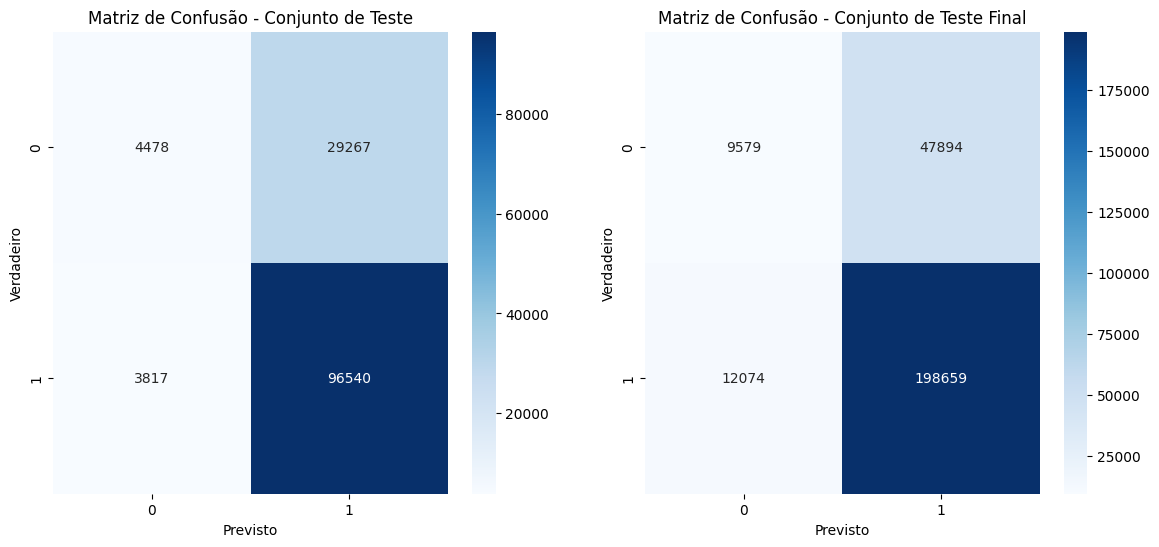

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Previsões para o conjunto de teste
final_predictions_test = ensemble_predictions(w1, y_preds)  # y_preds deve conter as previsões de cada modelo para X_test
final_accuracy_test = accuracy_score(y_test, np.round(final_predictions_test))
print("Acurácia no conjunto de teste:", final_accuracy_test)

# Previsões para o conjunto de teste final
# Aqui você precisaria gerar y_preds para X_test_final, da mesma forma que fez para X_test
y_pred1_final = model1.predict(X_test_final)
y_pred2_final = model2.predict(X_test_final)
y_pred3_final = model3.predict(X_test_final)
y_pred4_final = model4.predict(X_test_final)
y_pred5_final = model5.predict(X_test_final)
y_preds_final = [y_pred1_final, y_pred2_final, y_pred3_final, y_pred4_final, y_pred5_final]

final_predictions_test_final = ensemble_predictions(w1, y_preds_final)
final_accuracy_test_final = accuracy_score(y_test_final, np.round(final_predictions_test_final))
print("Acurácia no conjunto de teste final:", final_accuracy_test_final)

# Matriz de Confusão para o conjunto de teste
conf_matrix_test = confusion_matrix(y_test, final_predictions_test)

# Matriz de Confusão para o conjunto de teste final
conf_matrix_test_final = confusion_matrix(y_test_final, final_predictions_test_final)

# Plotando as matrizes de confusão
plt.figure(figsize=(14, 6))

# Para o conjunto de teste
plt.subplot(1, 2, 1)
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Conjunto de Teste')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')

# Para o conjunto de teste final
plt.subplot(1, 2, 2)
sns.heatmap(conf_matrix_test_final, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Conjunto de Teste Final')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')

plt.show()


In [ ]:
final_predictions_test_final = ensemble_predictions(w1, y_preds_final)
ensemble_predictions_by_scenario.append(final_predictions_test_final.copy())  # <- adicionar aqui

In [ ]:
# Intervalo 0.8

In [ ]:
# Esse caminho é para otimizar o precision

from deap import base, creator, tools, algorithms
import numpy as np
from sklearn.metrics import precision_score

# Definindo o problema para maximizar o precision
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

def evaluate(weights):
    # Normalizando os pesos para que somem 1
    weights = np.array(weights)
    weights = np.abs(weights)
    weights /= np.sum(weights)


# Problema aqui
    # Obtendo as previsões ponderadas
    y_ensemble_pred = ensemble_predictions(weights, y_preds)

    # Calculando o precision
    precision = precision_score(y_test, np.round(y_ensemble_pred), pos_label=1)

    return precision,  # Retorne o precision como uma tupla

toolbox = base.Toolbox()
toolbox.register("attr_float", np.random.random)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, n=5)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=1, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("evaluate", evaluate)

# Configuração da população e parâmetros da evolução
population = toolbox.population(n=1000)
ngen = 1000
cxpb = 0.6
mutpb = 0.05

# Adicionando o HallOfFame para elitismo
hof = tools.HallOfFame(1) # Mantém apenas o melhor indivíduo global

# Estatísticas para monitorar a evolução
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("std", np.std)
stats.register("min", np.min)
stats.register("max", np.max)


# Evoluindo a população para maximizar o precision
# Usando eaSimple para a evolução com HallOfFame e estatísticas
population, logbook = algorithms.eaSimple(population, toolbox, cxpb, mutpb, ngen,
                                            stats=stats, halloffame=hof, verbose=True)

# Pegando o melhor indivíduo (pesos otimizados para precision máximo)
best_ind = hof[0] # O melhor indivíduo está no HallOfFame
# Normalizando os pesos do melhor indivíduo para garantir que somem 1 e sejam positivos
final_best_weights = np.array(best_ind)
final_best_weights = np.abs(final_best_weights)
if np.sum(final_best_weights) == 0:
    print("Atenção: Os melhores pesos encontrados são todos zero. A normalização não é possível.")
else:
    final_best_weights /= np.sum(final_best_weights)


print("Melhores pesos encontrados para maximizar o precision (normalizados):", final_best_weights)
print("Precision máximo alcançado:", best_ind.fitness.values[0])

/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


gen	nevals	avg     	std      	min     	max     
0  	1000  	0.756701	0.0048283	0.748358	0.766224
1  	655   	0.761128	0.00338101	0.749044	0.766092
2  	612   	0.763593	0.00183732	0.750337	0.766094
3  	625   	0.764676	0.00146279	0.748423	0.766295
4  	620   	0.765226	0.00111596	0.748408	0.766643
5  	584   	0.765534	0.00130695	0.748371	0.766915
6  	618   	0.765815	0.00137826	0.7484  	0.76705 
7  	602   	0.766105	0.0013132 	0.748817	0.767289
8  	623   	0.766444	0.00102562	0.750077	0.767293
9  	649   	0.766647	0.00136285	0.748363	0.767338
10 	632   	0.766921	0.000892658	0.750908	0.767338
11 	628   	0.767082	0.000473855	0.75919 	0.767338
12 	620   	0.767117	0.000804647	0.750929	0.767346
13 	579   	0.767188	0.00057789 	0.75464 	0.767346
14 	620   	0.767185	0.000719765	0.749236	0.767352
15 	649   	0.767219	0.00046883 	0.756589	0.767356
16 	592   	0.767239	0.00041234 	0.760119	0.767358
17 	616   	0.767232	0.0006308  	0.756069	0.767356
18 	690   	0.767249	0.000456972	0.759902	0.76736 
19 	637   	0.

In [ ]:
w2 = final_best_weights.copy()

In [ ]:
final_predictions = ensemble_predictions(w2, y_preds)
final_accuracy = np.mean(np.round(final_predictions) == y_test)
print("Acurácia final do ensemble:", final_accuracy)

Acurácia final do ensemble: 0.7176414331389087


In [ ]:
print(best_ind)

[5.699717708721865, 0.009852672799649742, 0.523338907016172, -0.013497440904970981, -0.0001801078194781277]


In [ ]:
pd.DataFrame(confusion_matrix(np.round(final_predictions), y_test))

,0,1
0,4478,3816
1,29267,96541


Acurácia no conjunto de teste: 0.7532997270734217
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 412us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 392us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 341us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 4s 416us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 405us/step
Acurácia no conjunto de teste final: 0.7764069409334616


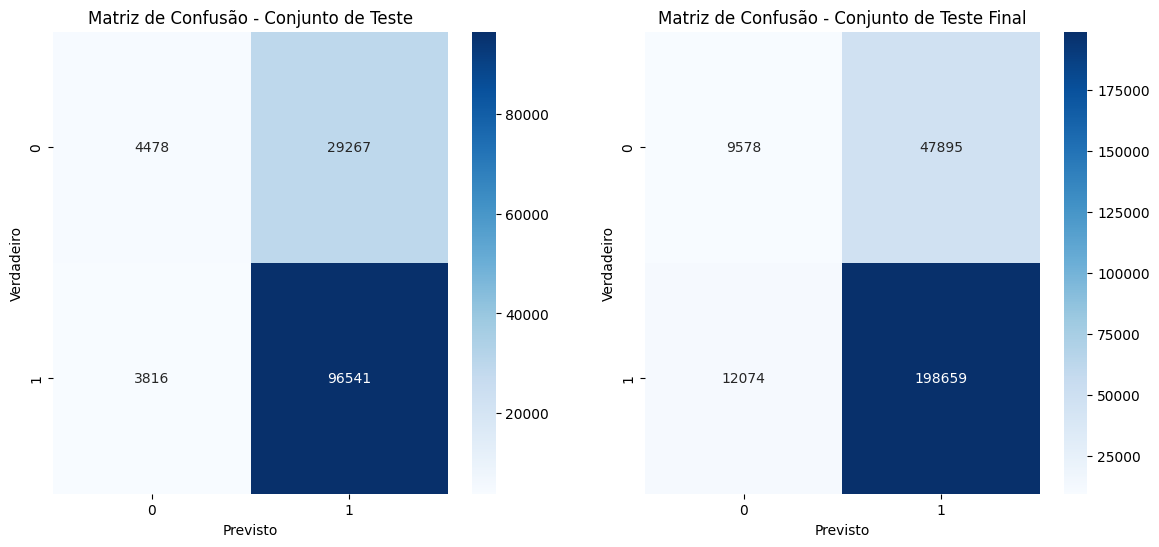

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Previsões para o conjunto de teste
final_predictions_test = ensemble_predictions(w2, y_preds)  # y_preds deve conter as previsões de cada modelo para X_test
final_accuracy_test = accuracy_score(y_test, np.round(final_predictions_test))
print("Acurácia no conjunto de teste:", final_accuracy_test)

# Previsões para o conjunto de teste final
# Aqui você precisaria gerar y_preds para X_test_final, da mesma forma que fez para X_test
y_pred1_final = model1.predict(X_test_final)
y_pred2_final = model2.predict(X_test_final)
y_pred3_final = model3.predict(X_test_final)
y_pred4_final = model4.predict(X_test_final)
y_pred5_final = model5.predict(X_test_final)
y_preds_final = [y_pred1_final, y_pred2_final, y_pred3_final, y_pred4_final, y_pred5_final]

final_predictions_test_final = ensemble_predictions(w2, y_preds_final)
final_accuracy_test_final = accuracy_score(y_test_final, np.round(final_predictions_test_final))
print("Acurácia no conjunto de teste final:", final_accuracy_test_final)

# Matriz de Confusão para o conjunto de teste
conf_matrix_test = confusion_matrix(y_test, final_predictions_test)

# Matriz de Confusão para o conjunto de teste final
conf_matrix_test_final = confusion_matrix(y_test_final, final_predictions_test_final)

# Plotando as matrizes de confusão
plt.figure(figsize=(14, 6))

# Para o conjunto de teste
plt.subplot(1, 2, 1)
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Conjunto de Teste')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')

# Para o conjunto de teste final
plt.subplot(1, 2, 2)
sns.heatmap(conf_matrix_test_final, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Conjunto de Teste Final')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')

plt.show()


In [ ]:
def ensemble_predictions(weights, y_preds):
    # Inicializa weighted_preds como float64 para evitar conflitos de tipo
    weighted_preds = np.zeros_like(y_preds[0], dtype=np.float64)
    for weight, y_pred in zip(weights, y_preds):
        weighted_preds += weight * y_pred

    # Aplicando o limiar de 0.5 para binarizar as previsões
    final_preds = (weighted_preds > 0.8).astype("int32")

    return final_preds


# Conjunto de previsões dos quatro modelos
y_preds = [predictions11, predictions22, predictions33, predictions44, predictions55]

In [ ]:
y_preds

[array([[0.44669688],
        [0.67748606],
        [0.6145934 ],
        ...,
        [0.6753499 ],
        [0.9111109 ],
        [0.51325893]], dtype=float32),
 array([[0.48519096],
        [0.6820295 ],
        [0.59564185],
        ...,
        [0.6682757 ],
        [0.94722354],
        [0.5754225 ]], dtype=float32),
 array([[0.4844518 ],
        [0.6399907 ],
        [0.5784628 ],
        ...,
        [0.63814914],
        [0.93682843],
        [0.5895775 ]], dtype=float32),
 array([[0.51077294],
        [0.29333735],
        [0.6244079 ],
        ...,
        [0.6756178 ],
        [0.94871193],
        [0.56016374]], dtype=float32),
 array([[0.8142921],
        [0.8142921],
        [0.8142921],
        ...,
        [0.8142921],
        [0.8142921],
        [0.8142921]], dtype=float32)]

In [ ]:
pip install deap

In [ ]:
# Esse caminho é para otimizar o precision

from deap import base, creator, tools, algorithms
import numpy as np
from sklearn.metrics import precision_score

# Definindo o problema para maximizar o precision
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

def evaluate(weights):
    # Normalizando os pesos para que somem 1
    weights = np.array(weights)
    weights = np.abs(weights)
    weights /= np.sum(weights)


# Problema aqui
    # Obtendo as previsões ponderadas
    y_ensemble_pred = ensemble_predictions(weights, y_preds)

    # Calculando o precision
    precision = precision_score(y_test, np.round(y_ensemble_pred), pos_label=1)

    return precision,  # Retorne o precision como uma tupla

toolbox = base.Toolbox()
toolbox.register("attr_float", np.random.random)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, n=5)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=1, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("evaluate", evaluate)

# Configuração da população e parâmetros da evolução
population = toolbox.population(n=200)
ngen = 200
cxpb = 0.6
mutpb = 0.05

# Adicionando o HallOfFame para elitismo
hof = tools.HallOfFame(1) # Mantém apenas o melhor indivíduo global

# Estatísticas para monitorar a evolução
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("std", np.std)
stats.register("min", np.min)
stats.register("max", np.max)


# Evoluindo a população para maximizar o precision
# Usando eaSimple para a evolução com HallOfFame e estatísticas
population, logbook = algorithms.eaSimple(population, toolbox, cxpb, mutpb, ngen,
                                            stats=stats, halloffame=hof, verbose=True)

# Pegando o melhor indivíduo (pesos otimizados para precision máximo)
best_ind = hof[0] # O melhor indivíduo está no HallOfFame
# Normalizando os pesos do melhor indivíduo para garantir que somem 1 e sejam positivos
final_best_weights = np.array(best_ind)
final_best_weights = np.abs(final_best_weights)
if np.sum(final_best_weights) == 0:
    print("Atenção: Os melhores pesos encontrados são todos zero. A normalização não é possível.")
else:
    final_best_weights /= np.sum(final_best_weights)


print("Melhores pesos encontrados para maximizar o precision (normalizados):", final_best_weights)
print("Precision máximo alcançado:", best_ind.fitness.values[0])


/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


gen	nevals	avg     	std       	min     	max     
0  	200   	0.842803	0.00199867	0.836876	0.847651
1  	123   	0.844548	0.00124863	0.840453	0.847651
2  	130   	0.845285	0.00112192	0.837747	0.847651
3  	123   	0.84591 	0.000931195	0.843036	0.848221
4  	129   	0.846667	0.00105092 	0.841995	0.849985
5  	123   	0.847312	0.00103478 	0.843532	0.84993 
6  	132   	0.84782 	0.00126832 	0.84174 	0.849988
7  	118   	0.848708	0.00116918 	0.842916	0.850229
8  	119   	0.849461	0.000747424	0.845029	0.850442
9  	110   	0.849799	0.000717603	0.84349 	0.850442
10 	124   	0.849945	0.00073446 	0.845364	0.850507
11 	127   	0.85017 	0.000481577	0.846114	0.850547
12 	124   	0.850184	0.000861774	0.84219 	0.850584
13 	119   	0.850399	0.000192767	0.848816	0.850621
14 	134   	0.850398	0.000428833	0.846067	0.850633
15 	134   	0.850506	0.000170179	0.848833	0.850633
16 	106   	0.850532	0.000152194	0.849464	0.850633
17 	111   	0.850533	0.000296903	0.847692	0.850633
18 	119   	0.850527	0.000517221	0.843446	0.850633
19 	

In [ ]:
w3 = final_best_weights.copy()

In [ ]:
final_predictions = ensemble_predictions(w3, y_preds)
final_accuracy = np.mean(np.round(final_predictions) == y_test)
print("Acurácia final do ensemble:", final_accuracy)


Acurácia final do ensemble: 0.5032336737942759


In [ ]:
print(best_ind)

[0.21676018499757246, -0.004425963491257601, -18.91474719637101, -0.0407641170855005, -0.002520823082489014]


In [ ]:
pd.DataFrame(confusion_matrix(np.round(final_predictions), y_test))

,0,1
0,23601,42577
1,10144,57780


Acurácia no conjunto de teste: 0.6068589581065159
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 4s 470us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 384us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 376us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 410us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 4s 435us/step
Acurácia no conjunto de teste final: 0.5600508564312506


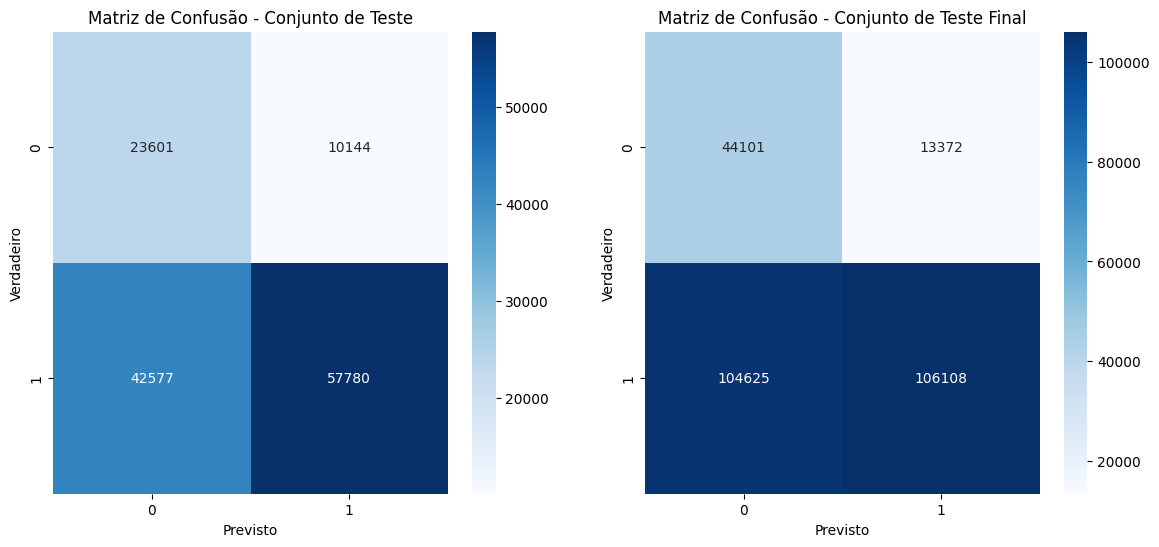

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Previsões para o conjunto de teste
final_predictions_test = ensemble_predictions(w3, y_preds)  # y_preds deve conter as previsões de cada modelo para X_test
final_accuracy_test = accuracy_score(y_test, np.round(final_predictions_test))
print("Acurácia no conjunto de teste:", final_accuracy_test)

# Previsões para o conjunto de teste final
# Aqui você precisaria gerar y_preds para X_test_final, da mesma forma que fez para X_test
y_pred1_final = model1.predict(X_test_final)
y_pred2_final = model2.predict(X_test_final)
y_pred3_final = model3.predict(X_test_final)
y_pred4_final = model4.predict(X_test_final)
y_pred5_final = model5.predict(X_test_final)
y_preds_final = [y_pred1_final, y_pred2_final, y_pred3_final, y_pred4_final, y_pred5_final]

final_predictions_test_final = ensemble_predictions(w3, y_preds_final)
final_accuracy_test_final = accuracy_score(y_test_final, np.round(final_predictions_test_final))
print("Acurácia no conjunto de teste final:", final_accuracy_test_final)

# Matriz de Confusão para o conjunto de teste
conf_matrix_test = confusion_matrix(y_test, final_predictions_test)

# Matriz de Confusão para o conjunto de teste final
conf_matrix_test_final = confusion_matrix(y_test_final, final_predictions_test_final)

# Plotando as matrizes de confusão
plt.figure(figsize=(14, 6))

# Para o conjunto de teste
plt.subplot(1, 2, 1)
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Conjunto de Teste')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')

# Para o conjunto de teste final
plt.subplot(1, 2, 2)
sns.heatmap(conf_matrix_test_final, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Conjunto de Teste Final')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')

plt.show()


In [ ]:
def ensemble_predictions(weights, y_preds):
    # Inicializa weighted_preds como float64 para evitar conflitos de tipo
    weighted_preds = np.zeros_like(y_preds[0], dtype=np.float64)
    for weight, y_pred in zip(weights, y_preds):
        weighted_preds += weight * y_pred

    # Aplicando o limiar de 0.5 para binarizar as previsões
    final_preds = (weighted_preds > 0.8).astype("int32")

    return final_preds


# Conjunto de previsões dos quatro modelos
y_preds = [predictions11, predictions22, predictions33, predictions44, predictions55]

In [ ]:
y_preds

[array([[0.44669688],
        [0.67748606],
        [0.6145934 ],
        ...,
        [0.6753499 ],
        [0.9111109 ],
        [0.51325893]], dtype=float32),
 array([[0.48519096],
        [0.6820295 ],
        [0.59564185],
        ...,
        [0.6682757 ],
        [0.94722354],
        [0.5754225 ]], dtype=float32),
 array([[0.4844518 ],
        [0.6399907 ],
        [0.5784628 ],
        ...,
        [0.63814914],
        [0.93682843],
        [0.5895775 ]], dtype=float32),
 array([[0.51077294],
        [0.29333735],
        [0.6244079 ],
        ...,
        [0.6756178 ],
        [0.94871193],
        [0.56016374]], dtype=float32),
 array([[0.8142921],
        [0.8142921],
        [0.8142921],
        ...,
        [0.8142921],
        [0.8142921],
        [0.8142921]], dtype=float32)]

In [ ]:
pip install deap

In [ ]:
# Esse caminho é para otimizar o precision

from deap import base, creator, tools, algorithms
import numpy as np
from sklearn.metrics import precision_score

# Definindo o problema para maximizar o precision
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

def evaluate(weights):
    # Normalizando os pesos para que somem 1
    weights = np.array(weights)
    weights = np.abs(weights)
    weights /= np.sum(weights)


# Problema aqui
    # Obtendo as previsões ponderadas
    y_ensemble_pred = ensemble_predictions(weights, y_preds)

    # Calculando o precision
    precision = precision_score(y_test, np.round(y_ensemble_pred), pos_label=1)

    return precision,  # Retorne o precision como uma tupla

toolbox = base.Toolbox()
toolbox.register("attr_float", np.random.random)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, n=5)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=1, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("evaluate", evaluate)

# Configuração da população e parâmetros da evolução
population = toolbox.population(n=1000)
ngen = 1000
cxpb = 0.6
mutpb = 0.05

# Adicionando o HallOfFame para elitismo
hof = tools.HallOfFame(1) # Mantém apenas o melhor indivíduo global

# Estatísticas para monitorar a evolução
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("std", np.std)
stats.register("min", np.min)
stats.register("max", np.max)


# Evoluindo a população para maximizar o precision
# Usando eaSimple para a evolução com HallOfFame e estatísticas
population, logbook = algorithms.eaSimple(population, toolbox, cxpb, mutpb, ngen,
                                            stats=stats, halloffame=hof, verbose=True)

# Pegando o melhor indivíduo (pesos otimizados para precision máximo)
best_ind = hof[0] # O melhor indivíduo está no HallOfFame
# Normalizando os pesos do melhor indivíduo para garantir que somem 1 e sejam positivos
final_best_weights = np.array(best_ind)
final_best_weights = np.abs(final_best_weights)
if np.sum(final_best_weights) == 0:
    print("Atenção: Os melhores pesos encontrados são todos zero. A normalização não é possível.")
else:
    final_best_weights /= np.sum(final_best_weights)


print("Melhores pesos encontrados para maximizar o precision (normalizados):", final_best_weights)
print("Precision máximo alcançado:", best_ind.fitness.values[0])


/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


gen	nevals	avg     	std       	min     	max     
0  	1000  	0.842948	0.00190822	0.835422	0.849324
1  	613   	0.844438	0.00144603	0.83746 	0.848623
2  	624   	0.845521	0.00119908	0.835892	0.850194
3  	596   	0.846392	0.000990971	0.840297	0.850124
4  	635   	0.847061	0.00106377 	0.839109	0.850055
5  	654   	0.847755	0.00102058 	0.841916	0.850049
6  	655   	0.848403	0.000919809	0.842327	0.850324
7  	670   	0.848961	0.000996998	0.835204	0.850418
8  	593   	0.849418	0.000823178	0.841167	0.850506
9  	599   	0.849739	0.000942488	0.831426	0.850541
10 	620   	0.85004 	0.000577312	0.843998	0.850558
11 	613   	0.850192	0.000561242	0.843888	0.850595
12 	632   	0.850312	0.00046199 	0.843976	0.850607
13 	613   	0.85042 	0.000242479	0.847394	0.850637
14 	611   	0.850452	0.000260238	0.846646	0.850662
15 	625   	0.850472	0.000260131	0.847385	0.850662
16 	602   	0.850498	0.000299493	0.84581 	0.850662
17 	603   	0.850529	0.000241801	0.846691	0.850662
18 	594   	0.850559	0.000149649	0.848155	0.850662
19 	

In [ ]:
w4 = final_best_weights.copy()

In [ ]:
final_predictions = ensemble_predictions(w4, y_preds)
final_accuracy = np.mean(np.round(final_predictions) == y_test)
print("Acurácia final do ensemble:", final_accuracy)


Acurácia final do ensemble: 0.5032336737942759


In [ ]:
print(best_ind)

[0.13027229438127957, 0.008294984664635952, 11.385304291790943, 0.02117740322120504, 0.0003384654397153434]


In [ ]:
pd.DataFrame(confusion_matrix(np.round(final_predictions), y_test))

,0,1
0,23602,42576
1,10143,57781


Acurácia no conjunto de teste: 0.6068738721271868
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 4s 449us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 377us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 362us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 395us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 389us/step
Acurácia no conjunto de teste final: 0.5600583133859794


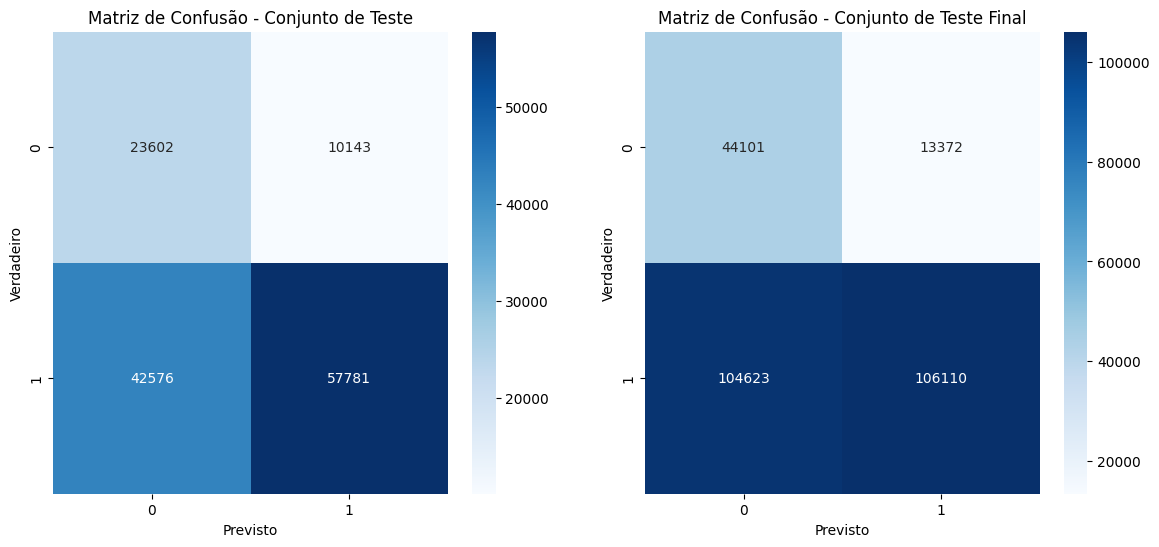

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Previsões para o conjunto de teste
final_predictions_test = ensemble_predictions(w4, y_preds)  # y_preds deve conter as previsões de cada modelo para X_test
final_accuracy_test = accuracy_score(y_test, np.round(final_predictions_test))
print("Acurácia no conjunto de teste:", final_accuracy_test)

# Previsões para o conjunto de teste final
# Aqui você precisaria gerar y_preds para X_test_final, da mesma forma que fez para X_test
y_pred1_final = model1.predict(X_test_final)
y_pred2_final = model2.predict(X_test_final)
y_pred3_final = model3.predict(X_test_final)
y_pred4_final = model4.predict(X_test_final)
y_pred5_final = model5.predict(X_test_final)
y_preds_final = [y_pred1_final, y_pred2_final, y_pred3_final, y_pred4_final, y_pred5_final]

final_predictions_test_final = ensemble_predictions(w4, y_preds_final)
final_accuracy_test_final = accuracy_score(y_test_final, np.round(final_predictions_test_final))
print("Acurácia no conjunto de teste final:", final_accuracy_test_final)

# Matriz de Confusão para o conjunto de teste
conf_matrix_test = confusion_matrix(y_test, final_predictions_test)

# Matriz de Confusão para o conjunto de teste final
conf_matrix_test_final = confusion_matrix(y_test_final, final_predictions_test_final)

# Plotando as matrizes de confusão
plt.figure(figsize=(14, 6))

# Para o conjunto de teste
plt.subplot(1, 2, 1)
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Conjunto de Teste')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')

# Para o conjunto de teste final
plt.subplot(1, 2, 2)
sns.heatmap(conf_matrix_test_final, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Conjunto de Teste Final')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')

plt.show()


In [ ]:
y_pred1_final = model1.predict(X_test_final)
pd.DataFrame(confusion_matrix(y_test_final, np.round(y_pred1_final)))

8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 391us/step


,0,1
0,9582,47891
1,12142,198591


In [ ]:
y_pred2_final = model2.predict(X_test_final)
pd.DataFrame(confusion_matrix(y_test_final, np.round(y_pred2_final)))

8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 383us/step


,0,1
0,7821,49652
1,9430,201303


In [ ]:
y_pred3_final = model3.predict(X_test_final)
pd.DataFrame(confusion_matrix(y_test_final, np.round(y_pred3_final)))

8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 357us/step


,0,1
0,9527,47946
1,12414,198319


In [ ]:
y_pred4_final = model4.predict(X_test_final)
pd.DataFrame(confusion_matrix(y_test_final, np.round(y_pred4_final)))

8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 402us/step


,0,1
0,8162,49311
1,10029,200704


In [ ]:
y_pred5_final = model5.predict(X_test_final)
pd.DataFrame(confusion_matrix(y_test_final, np.round(y_pred5_final)))

8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 402us/step


,0,1
0,0,57473
1,0,210733


In [ ]:
#drive.flush_and_unmount()

ROC AUC Score for Model 1: 0.6897
ROC AUC Score for Model 2: 0.6901
ROC AUC Score for Model 3: 0.6915
ROC AUC Score for Model 4: 0.6887
ROC AUC Score for Model 5: 0.5000


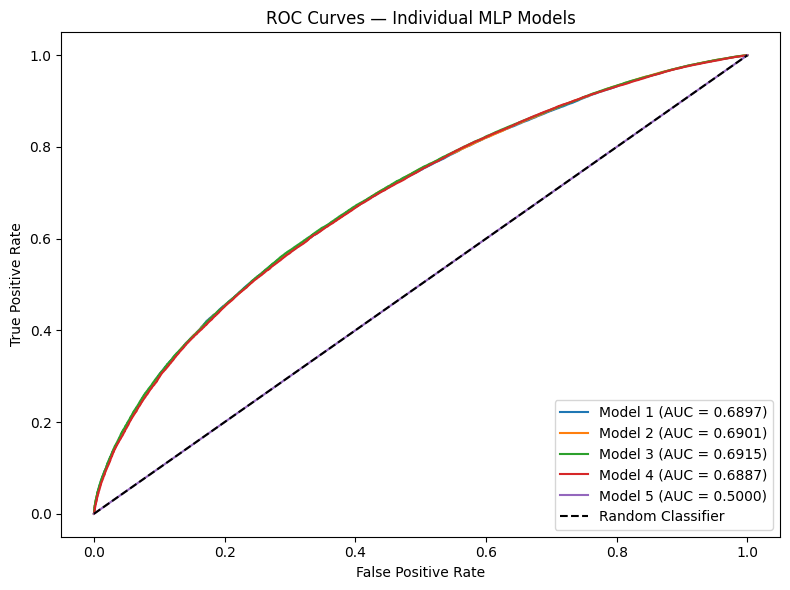

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# AUC scores
auc_score1 = roc_auc_score(y_test, predictions11.flatten())
auc_score2 = roc_auc_score(y_test, predictions22.flatten())
auc_score3 = roc_auc_score(y_test, predictions33.flatten())
auc_score4 = roc_auc_score(y_test, predictions44.flatten())
auc_score5 = roc_auc_score(y_test, predictions55.flatten())


print(f"ROC AUC Score for Model 1: {auc_score1:.4f}")
print(f"ROC AUC Score for Model 2: {auc_score2:.4f}")
print(f"ROC AUC Score for Model 3: {auc_score3:.4f}")
print(f"ROC AUC Score for Model 4: {auc_score4:.4f}")
print(f"ROC AUC Score for Model 5: {auc_score5:.4f}")

# ROC Curves
models_info = [
    (predictions11, auc_score1, 'Model 1'),
    (predictions22, auc_score2, 'Model 2'),
    (predictions33, auc_score3, 'Model 3'),
    (predictions44, auc_score4, 'Model 4'),
    (predictions55, auc_score5, 'Model 5'),
]

plt.figure(figsize=(8, 6))
for preds, auc, label in models_info:
    fpr, tpr, _ = roc_curve(y_test, preds.flatten())
    plt.plot(fpr, tpr, label=f'{label} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Individual MLP Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
scenarios_weights = {
    'Scenario 1 (thr=0.5, pop=200)' : w1,
    'Scenario 2 (thr=0.5, pop=1000)': w2,
    'Scenario 3 (thr=0.8, pop=200)' : w3,
    'Scenario 4 (thr=0.8, pop=1000)': w4,
}

# Verificação: soma dos pesos de cada cenário
for name, weights in scenarios_weights.items():
    print(f"{name}: {weights} | Soma: {weights.sum():.6f}")

Scenario 1 (thr=0.5, pop=200): [9.11950223e-01 1.93487759e-04 8.53321501e-02 2.49301112e-03
 3.11284092e-05] | Soma: 1.000000
Scenario 2 (thr=0.5, pop=1000): [9.12453130e-01 1.57728901e-03 8.37799779e-02 2.16077055e-03
 2.88329970e-05] | Soma: 1.000000
Scenario 3 (thr=0.8, pop=200): [1.13018259e-02 2.30768712e-04 9.86210539e-01 2.12543162e-03
 1.31435132e-04] | Soma: 1.000000
Scenario 4 (thr=0.8, pop=1000): [1.12834927e-02 7.18467415e-04 9.86134450e-01 1.83427393e-03
 2.93160746e-05] | Soma: 1.000000


8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 398us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 385us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 366us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 395us/step
8382/8382 ━━━━━━━━━━━━━━━━━━━━ 3s 399us/step


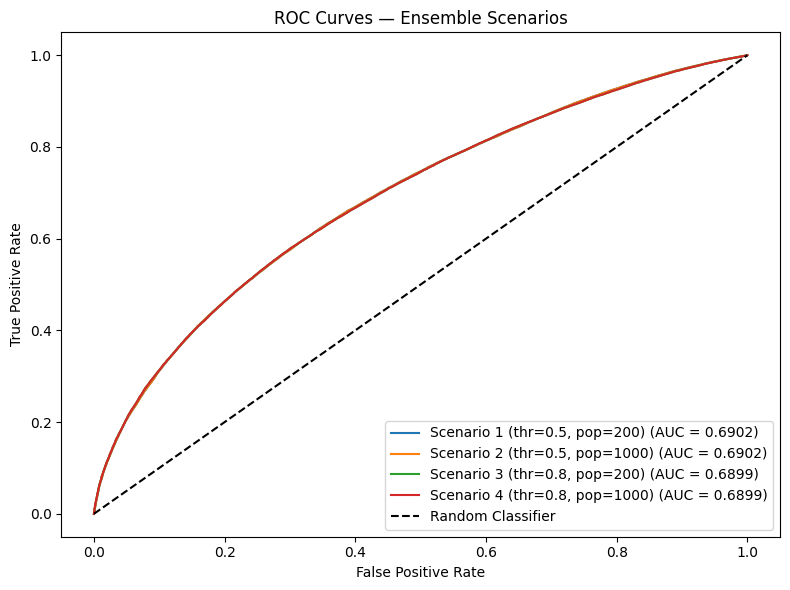

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_preds_final = [
    model1.predict(X_test_final).flatten(),
    model2.predict(X_test_final).flatten(),
    model3.predict(X_test_final).flatten(),
    model4.predict(X_test_final).flatten(),
    model5.predict(X_test_final).flatten(),
]

plt.figure(figsize=(8, 6))

for name, weights in scenarios_weights.items():
    preds = sum(w * p for w, p in zip(weights, y_preds_final))
    auc = roc_auc_score(y_test_final, preds)
    fpr, tpr, _ = roc_curve(y_test_final, preds)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Ensemble Scenarios')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves_ensembles.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import pandas as pd



models = [model1, model2, model3, model4, model5]
model_names = ['Model 1', 'Model 2', 'Model 3', 'Model 4', 'Model 5']

# Predições probabilísticas
probs = {}
preds = {}
errors = {}

threshold = 0.5

for name, model in zip(model_names, models):
    prob = model.predict(X_test).flatten()
    pred = (prob >= threshold).astype(int)
    error = (pred != y_test).astype(int)  # 1 onde errou, 0 onde acertou
    probs[name] = prob
    preds[name] = pred
    errors[name] = error

df_errors = pd.DataFrame(errors)
df_probs  = pd.DataFrame(probs)
df_preds  = pd.DataFrame(preds)

4191/4191 ━━━━━━━━━━━━━━━━━━━━ 2s 492us/step
4191/4191 ━━━━━━━━━━━━━━━━━━━━ 2s 387us/step
4191/4191 ━━━━━━━━━━━━━━━━━━━━ 2s 365us/step
4191/4191 ━━━━━━━━━━━━━━━━━━━━ 2s 396us/step
4191/4191 ━━━━━━━━━━━━━━━━━━━━ 2s 414us/step


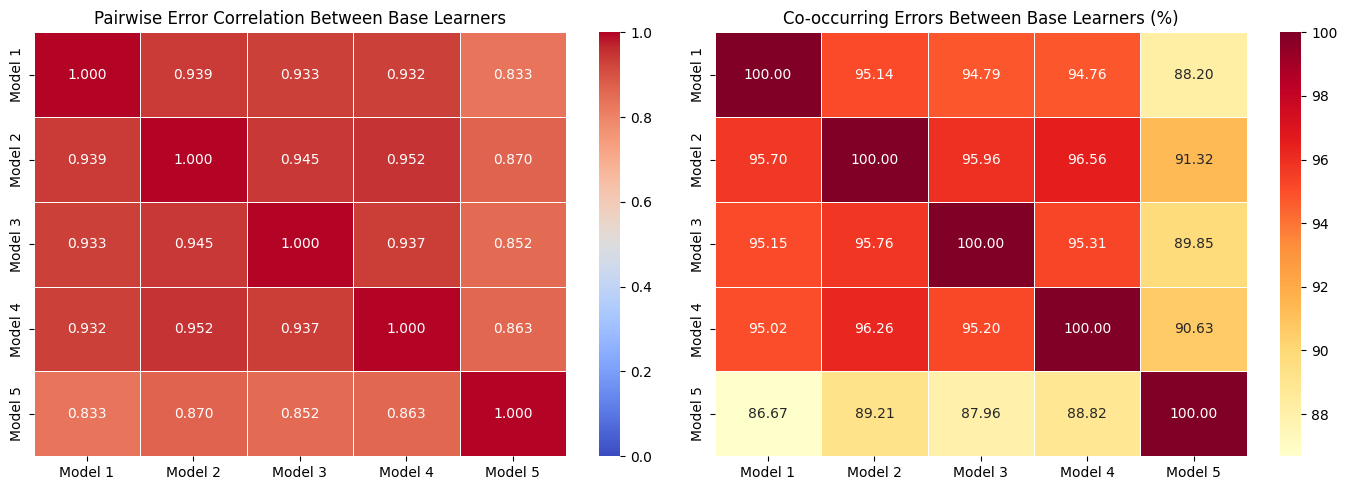


Error Correlation Matrix:
         Model 1  Model 2  Model 3  Model 4  Model 5
Model 1   1.0000   0.9392   0.9332   0.9321   0.8326
Model 2   0.9392   1.0000   0.9451   0.9524   0.8704
Model 3   0.9332   0.9451   1.0000   0.9371   0.8522
Model 4   0.9321   0.9524   0.9371   1.0000   0.8631
Model 5   0.8326   0.8704   0.8522   0.8631   1.0000

Co-occurring Errors (%):
         Model 1  Model 2  Model 3  Model 4  Model 5
Model 1   100.00    95.14    94.79    94.76    88.20
Model 2    95.70   100.00    95.96    96.56    91.32
Model 3    95.15    95.76   100.00    95.31    89.85
Model 4    95.02    96.26    95.20   100.00    90.63
Model 5    86.67    89.21    87.96    88.82   100.00


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlação de erros (Pearson)
error_corr = df_errors.corr()

# Coincidência de erros (% de instâncias em que ambos os modelos erram simultaneamente)
n = len(y_test)
co_error_matrix = pd.DataFrame(index=model_names, columns=model_names, dtype=float)

for m1 in model_names:
    for m2 in model_names:
        errors_m1 = (df_errors[m1] == 1).sum()
        co_errors  = ((df_errors[m1] == 1) & (df_errors[m2] == 1)).sum()
        # Dado que m1 errou, qual % também foi erro de m2?
        co_error_matrix.loc[m1, m2] = co_errors / errors_m1 * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap de correlação de erros
sns.heatmap(error_corr, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=0, vmax=1, ax=axes[0], linewidths=0.5)
axes[0].set_title('Pairwise Error Correlation Between Base Learners')

# Heatmap de co-ocorrência de erros
sns.heatmap(co_error_matrix.astype(float), annot=True, fmt='.2f', cmap='YlOrRd',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Co-occurring Errors Between Base Learners (%)')

plt.tight_layout()
plt.savefig('error_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

# Tabela resumo para o paper
print("\nError Correlation Matrix:")
print(error_corr.round(4).to_string())

print("\nCo-occurring Errors (%):")
print(co_error_matrix.round(2).to_string())

In [ ]:
# import pickle
# import os

# # 1. Montar o Drive (se ainda não montou)
# from google.colab import drive
# drive.mount('/content/drive')

# # 2. Criar pasta
# os.makedirs('/content/drive/MyDrive/lending_club_experiment/', exist_ok=True)

# # 3. Salvar
# to_save = {
#     'y_preds'       : y_preds,
#     'y_pred1_final' : y_pred1_final,  # <- vírgulas faltavam aqui
#     'y_pred2_final' : y_pred2_final,
#     'y_pred3_final' : y_pred3_final,
#     'y_pred4_final' : y_pred4_final,
#     'y_pred5_final' : y_pred5_final,
#     'w1'            : w1,
#     'w2'            : w2,
#     'w3'            : w3,
#     'w4'            : w4,
#     'y_test'        : y_test,
#     'y_test_final'  : y_test_final,
# }

# save_path = '/content/drive/MyDrive/lending_club_experiment/experiment_data.pkl'

# with open(save_path, 'wb') as f:
#     pickle.dump(to_save, f)

# print(f"Salvo com sucesso em: {save_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Salvo com sucesso em: /content/drive/MyDrive/lending_club_experiment/experiment_data.pkl


In [ ]:
# from google.colab import drive
# import pickle

# # 1. Montar o Drive
# drive.mount('/content/drive')

# # 2. Carregar
# save_path = '/content/drive/MyDrive/lending_club_experiment/experiment_data.pkl'

# with open(save_path, 'rb') as f:
#     data = pickle.load(f)

# # 3. Restaurar as variáveis
# y_preds       = data['y_preds']
# y_pred1_final = data['y_pred1_final']
# y_pred2_final = data['y_pred2_final']
# y_pred3_final = data['y_pred3_final']
# y_pred4_final = data['y_pred4_final']
# w1            = data['w1']
# w2            = data['w2']
# w3            = data['w3']
# w4            = data['w4']
# y_test        = data['y_test']
# y_test_final  = data['y_test_final']
# #X_test        = data['X_test']
# #X_test_final  = data['X_test_final']

# print("Dados carregados com sucesso!")
# print(f"y_preds:       {len(y_preds)} modelos")
# print(f"y_pred1_final: {len(y_pred1_final)} modelos")
# print(f"y_test:        {y_test.shape}")
# print(f"y_test_final:  {y_test_final.shape}")

Aqui começam os resgatados da gravação:

In [ ]:
import numpy as np
import pandas as pd

threshold = 0.5
model_names = ['Model 1', 'Model 2', 'Model 3', 'Model 4', 'Model 5']

# Usando os preds já salvos ao invés de rodar os modelos novamente
saved_preds = [
    y_pred1_final.flatten(),
    y_pred2_final.flatten(),
    y_pred3_final.flatten(),
    y_pred4_final.flatten(),
    y_pred5_final.flatten(),
]

probs  = {}
preds  = {}
errors = {}

for name, prob in zip(model_names, saved_preds):
    pred  = (prob >= threshold).astype(int)
    error = (pred != y_test_final).astype(int)  # <- y_test_final, não y_test
    probs[name]  = prob
    preds[name]  = pred
    errors[name] = error

df_errors = pd.DataFrame(errors)
df_probs  = pd.DataFrame(probs)
df_preds  = pd.DataFrame(preds)

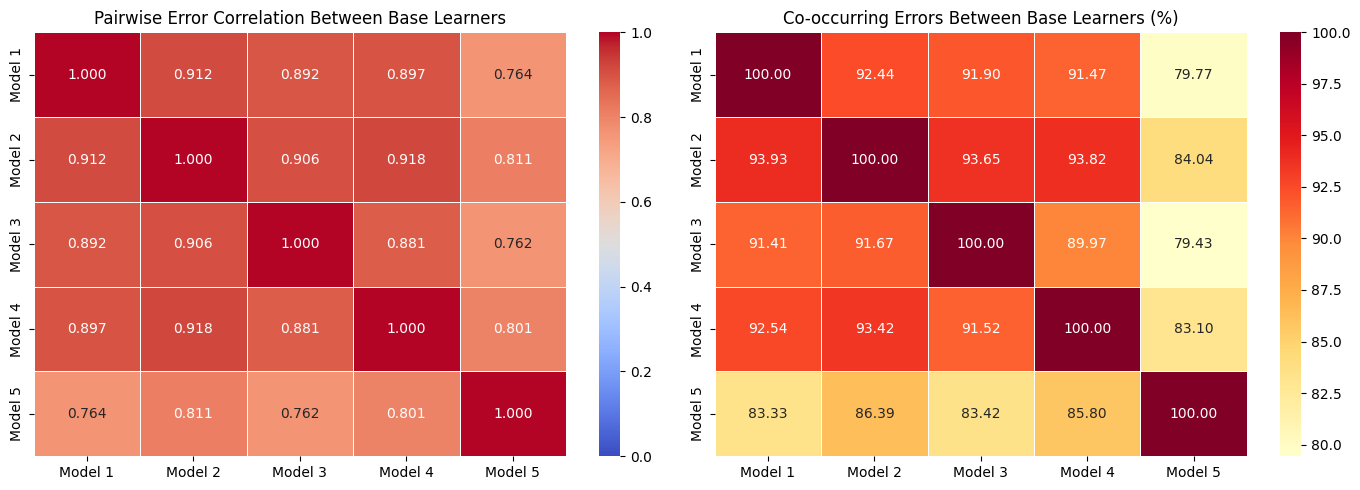


Error Correlation Matrix:
         Model 1  Model 2  Model 3  Model 4  Model 5
Model 1   1.0000   0.9123   0.8924   0.8972   0.7636
Model 2   0.9123   1.0000   0.9056   0.9181   0.8110
Model 3   0.8924   0.9056   1.0000   0.8809   0.7618
Model 4   0.8972   0.9181   0.8809   1.0000   0.8011
Model 5   0.7636   0.8110   0.7618   0.8011   1.0000

Co-occurring Errors (%):
         Model 1  Model 2  Model 3  Model 4  Model 5
Model 1   100.00    92.44    91.90    91.47    79.77
Model 2    93.93   100.00    93.65    93.82    84.04
Model 3    91.41    91.67   100.00    89.97    79.43
Model 4    92.54    93.42    91.52   100.00    83.10
Model 5    83.33    86.39    83.42    85.80   100.00


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlação de erros (Pearson)
error_corr = df_errors.corr()

# Coincidência de erros (% de instâncias em que ambos os modelos erram simultaneamente)
n = len(y_test)
co_error_matrix = pd.DataFrame(index=model_names, columns=model_names, dtype=float)

for m1 in model_names:
    for m2 in model_names:
        errors_m1 = (df_errors[m1] == 1).sum()
        co_errors  = ((df_errors[m1] == 1) & (df_errors[m2] == 1)).sum()
        # Dado que m1 errou, qual % também foi erro de m2?
        co_error_matrix.loc[m1, m2] = co_errors / errors_m1 * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap de correlação de erros
sns.heatmap(error_corr, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=0, vmax=1, ax=axes[0], linewidths=0.5)
axes[0].set_title('Pairwise Error Correlation Between Base Learners')

# Heatmap de co-ocorrência de erros
sns.heatmap(co_error_matrix.astype(float), annot=True, fmt='.2f', cmap='YlOrRd',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Co-occurring Errors Between Base Learners (%)')

plt.tight_layout()
plt.savefig('error_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

# Tabela resumo para o paper
print("\nError Correlation Matrix:")
print(error_corr.round(4).to_string())

print("\nCo-occurring Errors (%):")
print(co_error_matrix.round(2).to_string())

In [ ]:
def ensemble_probabilities(weights, y_preds):
    weighted_preds = np.zeros_like(y_preds[0], dtype=np.float64)
    for weight, y_pred in zip(weights, y_preds):
        weighted_preds += weight * y_pred
    return weighted_preds

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np

# Configuração
models_info = [
    (y_pred1_final.flatten(), 'Model 1'),
    (y_pred2_final.flatten(), 'Model 2'),
    (y_pred3_final.flatten(), 'Model 3'),
    (y_pred4_final.flatten(), 'Model 4'),
    (y_pred5_final.flatten(), 'Model 5'),


]

# Regenerar predições dos ensembles
y_preds_final = [y_pred1_final, y_pred2_final, y_pred3_final, y_pred4_final]

final_predictions_s1 = ensemble_probabilities(w1, y_preds_final)
final_predictions_s2 = ensemble_probabilities(w2, y_preds_final)
final_predictions_s3 = ensemble_probabilities(w3, y_preds_final)
final_predictions_s4 = ensemble_probabilities(w4, y_preds_final)

ensembles_info = [
    (final_predictions_s1.flatten(), 'Scenario 1 (thr=0.5)'),
    (final_predictions_s2.flatten(), 'Scenario 2 (thr=0.5)'),
    (final_predictions_s3.flatten(), 'Scenario 3 (thr=0.8)'),
    (final_predictions_s4.flatten(), 'Scenario 4 (thr=0.8)'),
]





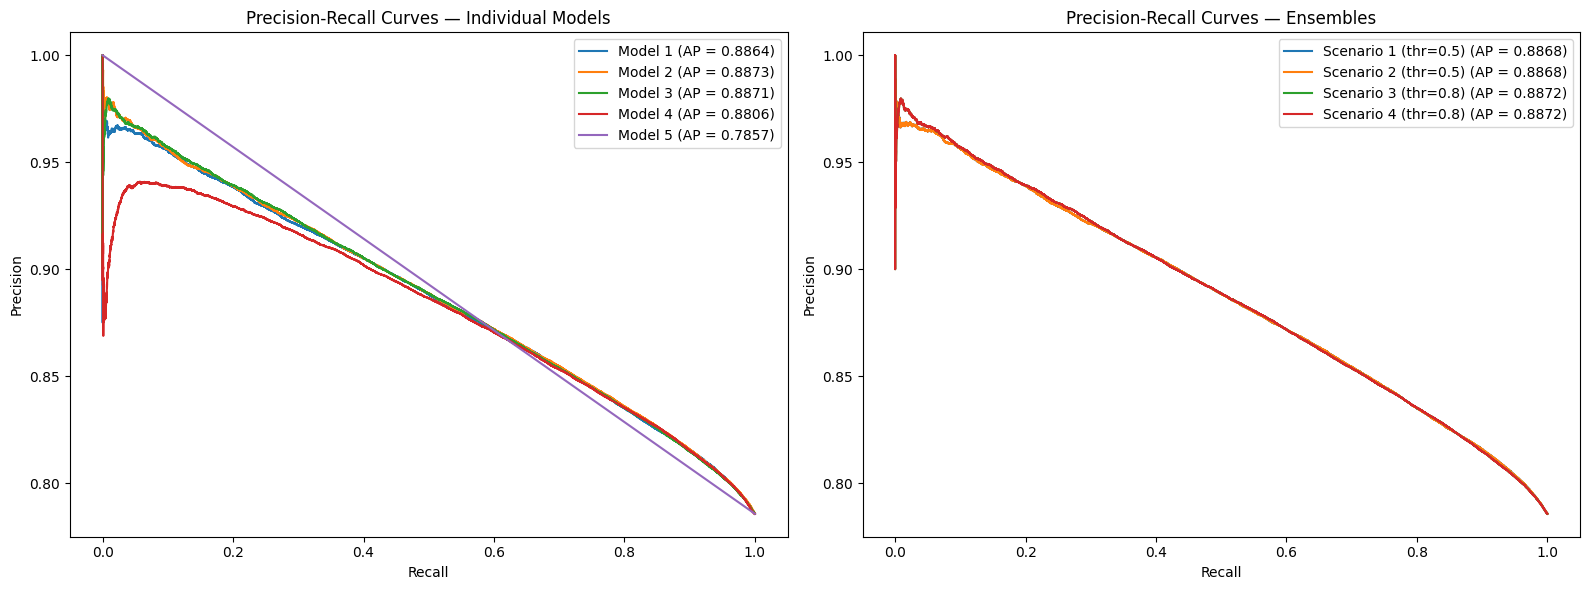

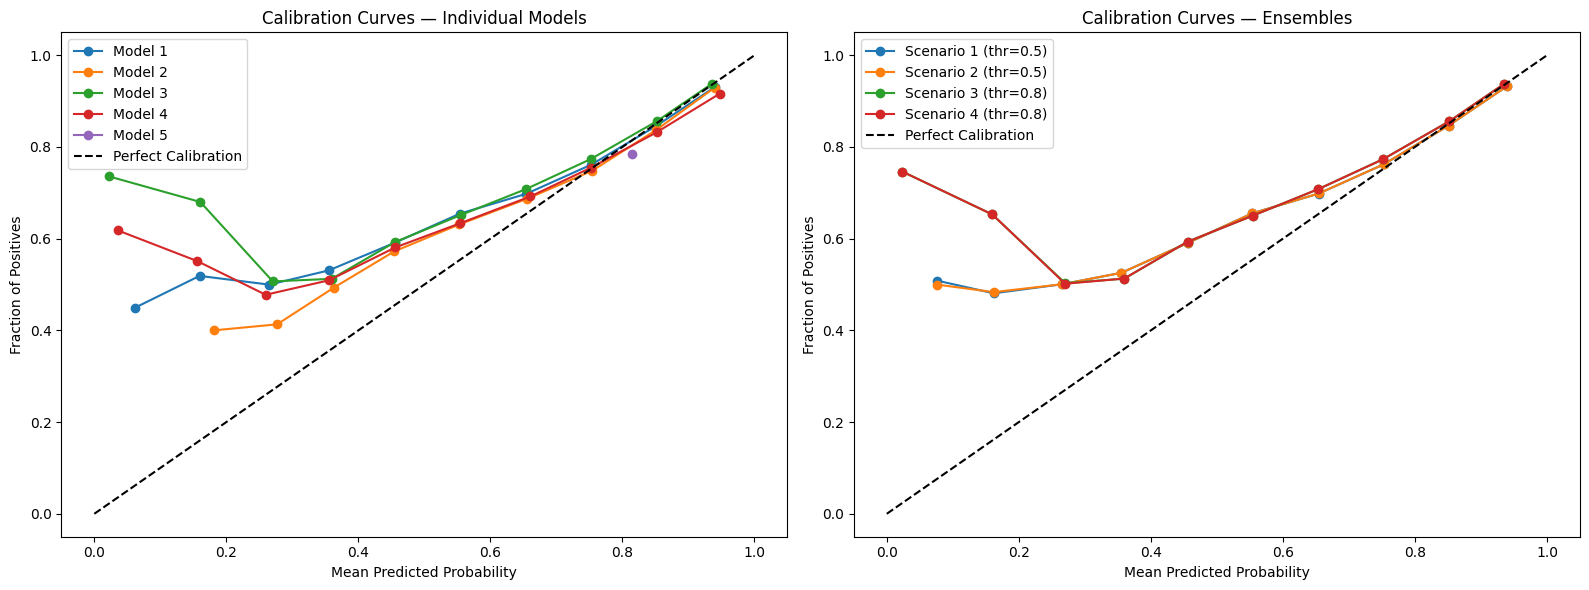

Cost FP (principal lost):      $14,422
Cost FN (interest revenue lost): $6,562

                          TP     FP      FN  Revenue TP ($)  Cost FP ($)   Cost FN ($)  Net Profit ($)
Model                                                                                                 
Model 1               198591  47891   12142    1.303156e+09    690684002  7.967593e+07    5.327962e+08
Model 2               201303  49652    9430    1.320952e+09    716081144  6.187975e+07    5.429914e+08
Model 3               198319  47946   12414    1.301371e+09    691477212  8.146079e+07    5.284333e+08
Model 4               200704  49311   10029    1.317022e+09    711163242  6.581040e+07    5.400480e+08
Model 5               210733  57473       0    1.382832e+09    828875606  0.000000e+00    5.539564e+08
Scenario 1 (thr=0.5)  198658  47893   12075    1.303596e+09    690712846  7.923627e+07    5.336467e+08
Scenario 2 (thr=0.5)  198657  47893   12076    1.303589e+09    690712846  7.924283e+07    5.3363

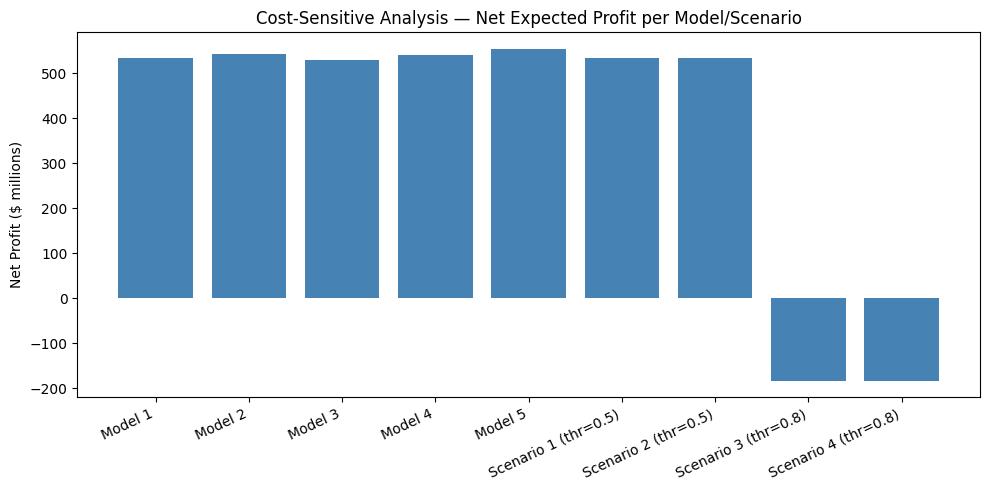

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd

# ── Bloco 1: Precision-Recall Curves ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for preds, label in models_info:
    precision, recall, _ = precision_recall_curve(y_test_final, preds)
    ap = average_precision_score(y_test_final, preds)
    axes[0].plot(recall, precision, label=f'{label} (AP = {ap:.4f})')

axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curves — Individual Models')
axes[0].legend(loc='upper right')

for preds, label in ensembles_info:
    precision, recall, _ = precision_recall_curve(y_test_final, preds)
    ap = average_precision_score(y_test_final, preds)
    axes[1].plot(recall, precision, label=f'{label} (AP = {ap:.4f})')

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves — Ensembles')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('precision_recall_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Bloco 2: Calibration Curves ───────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for preds, label in models_info:
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_test_final, preds, n_bins=10
    )
    axes[0].plot(mean_predicted_value, fraction_of_positives, marker='o', label=label)

axes[0].plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives')
axes[0].set_title('Calibration Curves — Individual Models')
axes[0].legend(loc='upper left')

for preds, label in ensembles_info:
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_test_final, preds, n_bins=10
    )
    axes[1].plot(mean_predicted_value, fraction_of_positives, marker='o', label=label)

axes[1].plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Fraction of Positives')
axes[1].set_title('Calibration Curves — Ensembles')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.savefig('calibration_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Bloco 3: Cost-Sensitive Analysis ──────────────────────────────────────────

avg_loan    = 14422
rate        = 0.13
term_years  = 42 / 12          # 3.5 anos
cost_FP     = avg_loan                        # perde o principal
cost_FN     = avg_loan * rate * term_years    # perde a receita de juros = $5,880

print(f"Cost FP (principal lost):      ${cost_FP:,.0f}")
print(f"Cost FN (interest revenue lost): ${cost_FN:,.0f}")
print()

all_info = [
    # modelos individuais — usar threshold correspondente
    ((y_pred1_final.flatten() > 0.5).astype(int), 'Model 1'),
    ((y_pred2_final.flatten() > 0.5).astype(int), 'Model 2'),
    ((y_pred3_final.flatten() > 0.5).astype(int), 'Model 3'),
    ((y_pred4_final.flatten() > 0.5).astype(int), 'Model 4'),
    ((y_pred5_final.flatten() > 0.5).astype(int), 'Model 5'),
    # ensembles — threshold já aplicado nas probabilidades
    ((final_predictions_s1.flatten() > 0.5).astype(int), 'Scenario 1 (thr=0.5)'),
    ((final_predictions_s2.flatten() > 0.5).astype(int), 'Scenario 2 (thr=0.5)'),
    ((final_predictions_s3.flatten() > 0.8).astype(int), 'Scenario 3 (thr=0.8)'),
    ((final_predictions_s4.flatten() > 0.8).astype(int), 'Scenario 4 (thr=0.8)'),
]


results = []
for preds_binary, label in all_info:
    tn, fp, fn, tp = confusion_matrix(y_test_final, preds_binary).ravel()

    revenue_tp   = tp * avg_loan * rate * term_years   # receita dos VP
    cost_fp      = fp * avg_loan                        # perda do principal
    cost_fn      = fn * avg_loan * rate * term_years   # receita perdida
    net_profit   = revenue_tp - cost_fp - cost_fn

    results.append({
        'Model'           : label,
        'TP'              : tp,
        'FP'              : fp,
        'FN'              : fn,
        'Revenue TP ($)'  : revenue_tp,
        'Cost FP ($)'     : cost_fp,
        'Cost FN ($)'     : cost_fn,
        'Net Profit ($)'  : net_profit,
    })

df_cost = pd.DataFrame(results).set_index('Model')
print(df_cost.to_string())

# Plot do lucro líquido
plt.figure(figsize=(10, 5))
plt.bar(df_cost.index, df_cost['Net Profit ($)'] / 1e6, color='steelblue')
plt.xticks(rotation=25, ha='right')
plt.ylabel('Net Profit ($ millions)')
plt.title('Cost-Sensitive Analysis — Net Expected Profit per Model/Scenario')
plt.tight_layout()
plt.savefig('cost_sensitive.png', dpi=300, bbox_inches='tight')
plt.show()

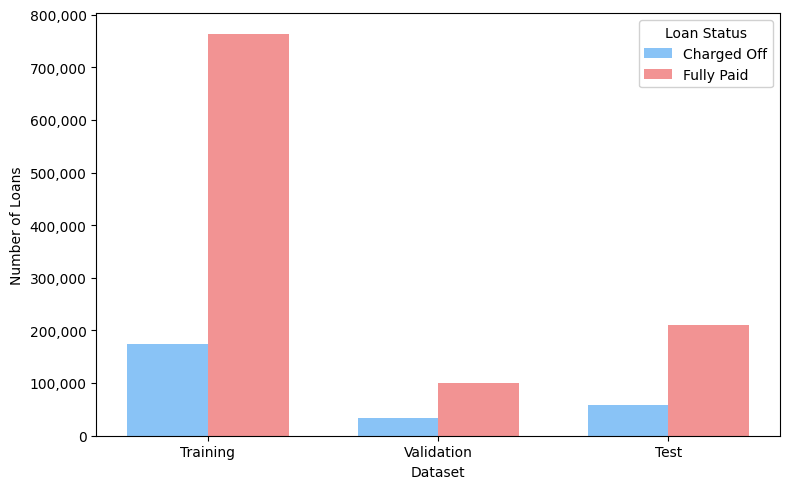

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Contagem de cada classe por base
datasets = {
    'Training': y_train,
    'Validation': y_test,
    'Test': y_test_final
}

charged_off_counts = []
fully_paid_counts = []

for name, y in datasets.items():
    counts = pd.Series(y).value_counts()
    charged_off_counts.append(counts.get(0, 0))
    fully_paid_counts.append(counts.get(1, 0))

# Configuração do gráfico
x = np.arange(len(datasets))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width/2, charged_off_counts, width,
               label='Charged Off', color='#74b9f5', alpha=0.85)
bars2 = ax.bar(x + width/2, fully_paid_counts, width,
               label='Fully Paid', color='#f08080', alpha=0.85)

# Eixos e legendas
ax.set_xlabel('Dataset')
ax.set_ylabel('Number of Loans')
ax.set_xticks(x)
ax.set_xticklabels(datasets.keys())
ax.legend(title='Loan Status', framealpha=0.9)

# Formatação do eixo Y com separador de milhar
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'{int(val):,}'))

plt.tight_layout()
plt.savefig('loan_status_distribution.png', dpi=150)
plt.show()

ROC AUC Score for Model 1: 0.6897
ROC AUC Score for Model 2: 0.6909
ROC AUC Score for Model 3: 0.6898
ROC AUC Score for Model 4: 0.6861
ROC AUC Score for Model 5: 0.5000


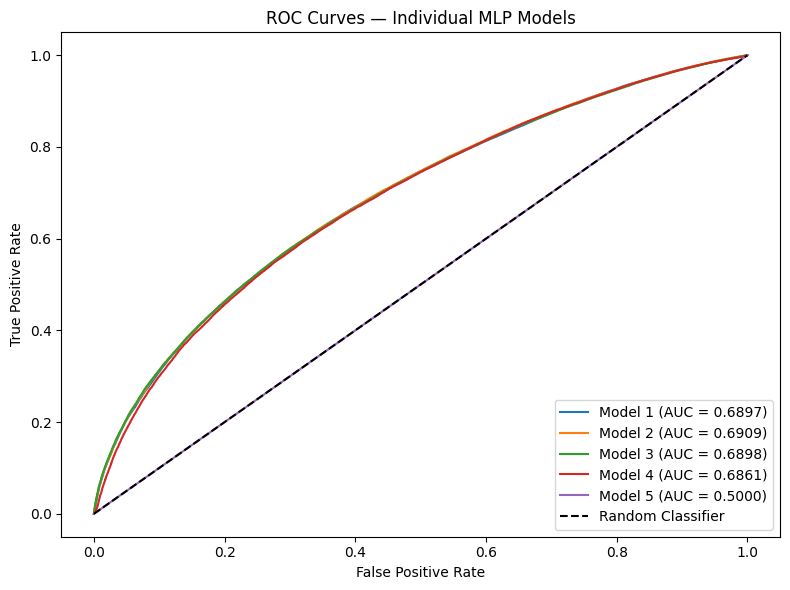

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# AUC scores
auc_score1 = roc_auc_score(y_test_final, predictions111.flatten())
auc_score2 = roc_auc_score(y_test_final, predictions222.flatten())
auc_score3 = roc_auc_score(y_test_final, predictions333.flatten())
auc_score4 = roc_auc_score(y_test_final, predictions444.flatten())
auc_score5 = roc_auc_score(y_test_final, predictions555.flatten())


print(f"ROC AUC Score for Model 1: {auc_score1:.4f}")
print(f"ROC AUC Score for Model 2: {auc_score2:.4f}")
print(f"ROC AUC Score for Model 3: {auc_score3:.4f}")
print(f"ROC AUC Score for Model 4: {auc_score4:.4f}")
print(f"ROC AUC Score for Model 5: {auc_score5:.4f}")

# ROC Curves
models_info = [
    (predictions111, auc_score1, 'Model 1'),
    (predictions222, auc_score2, 'Model 2'),
    (predictions333, auc_score3, 'Model 3'),
    (predictions444, auc_score4, 'Model 4'),
    (predictions555, auc_score5, 'Model 5'),
]

plt.figure(figsize=(8, 6))
for preds, auc, label in models_info:
    fpr, tpr, _ = roc_curve(y_test_final, preds.flatten())
    plt.plot(fpr, tpr, label=f'{label} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Individual MLP Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
print(f"y_train:      {len(y_train):,} amostras")
print(f"y_test:       {len(y_test):,} amostras")
print(f"y_test_final: {len(y_test_final):,} amostras")
print(f"Total:        {len(y_train) + len(y_test) + len(y_test_final):,} amostras")

y_train:      938,718 amostras
y_test:       134,102 amostras
y_test_final: 268,206 amostras
Total:        1,341,026 amostras


In [ ]:
print(len(predictions44))

134102


In [ ]:
from sklearn.metrics import brier_score_loss

# Probabilidades dos modelos individuais
models_probs = {
    'Model 1': predictions111.flatten(),
    'Model 2': predictions222.flatten(),
    'Model 3': predictions333.flatten(),
    'Model 4': predictions444.flatten(),
    'Model 5': predictions555.flatten()
}

# Probabilidades dos ensembles já calculadas
ensembles_probs = {
    'Scenario 1 (thr=0.5)': final_predictions_s1.flatten(),
    'Scenario 2 (thr=0.5)': final_predictions_s2.flatten(),
    'Scenario 3 (thr=0.8)': final_predictions_s3.flatten(),
    'Scenario 4 (thr=0.8)': final_predictions_s4.flatten(),
}

# Calcular e exibir Brier Scores
print("Brier Score (lower is better):\n")
print("Individual Models:")
for name, probs in models_probs.items():
    bs = brier_score_loss(y_test_final, probs)
    print(f"  {name}: {bs:.6f}")

print("\nEnsemble Scenarios:")
for name, probs in ensembles_probs.items():
    bs = brier_score_loss(y_test_final, probs)
    print(f"  {name}: {bs:.6f}")

Brier Score (lower is better):

Individual Models:
  Model 1: 0.159370
  Model 2: 0.157186
  Model 3: 0.159285
  Model 4: 0.159640
  Model 5: 0.169185

Ensemble Scenarios:
  Scenario 1 (thr=0.5): 0.159155
  Scenario 2 (thr=0.5): 0.159154
  Scenario 3 (thr=0.8): 0.159251
  Scenario 4 (thr=0.8): 0.159247
